# Bird Strike Risk Intelligence
## Exploratory Analysis, Damage Risk Prediction, and Wildlife Hazard Insights

### Objective
This project analyzes historical bird strike records to identify operational
and wildlife-related risk patterns and develop a predictive model for aircraft
damage following a bird strike event.

### Scope
- Data quality assessment
- Exploratory safety analysis
- Wildlife hazard identification
- Risk factor analysis
- Predictive modeling
- Model explainability
- Operational safety recommendations
- Dashboard-ready data preparation

## 1. Problem Statement

Bird strikes represent a wildlife hazard in aviation because their consequences
can range from negligible operational impact to aircraft damage, aborted
take-offs, engine shutdowns, and injuries.

This analysis focuses on three questions:

1. When and under what operational conditions do bird strikes occur most frequently?
2. Which wildlife and flight characteristics are associated with higher damage rates?
3. Can historical event characteristics be used to estimate the probability that
   a bird strike results in aircraft damage?

### Prediction Scope

This dataset contains bird strike events only and does not contain all flights
without bird strikes.

Therefore, this project does **not** predict the probability of a bird strike occurring.

Instead, the predictive task is:

> Given that a bird strike has occurred, estimate the probability that the event
> causes aircraft damage.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import shap

from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    fbeta_score,
    brier_score_loss
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

In [3]:
df = pd.read_csv("/kaggle/input/datasets/iamtapendu/bird-strike-by-aircafts-data/Bird_strikes.csv")

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
df.head()

Rows    : 25,429
Columns : 26


,RecordID,AircraftType,AirportName,AltitudeBin,MakeModel,NumberStruck,NumberStruckActual,Effect,FlightDate,Damage,Engines,Operator,OriginState,FlightPhase,ConditionsPrecipitation,RemainsCollected?,RemainsSentToSmithsonian,Remarks,WildlifeSize,ConditionsSky,WildlifeSpecies,PilotWarned,Cost,Altitude,PeopleInjured,IsAircraftLarge?
0,202152,Airplane,LAGUARDIA NY,"(1000, 2000]",B-737-400,Over 100,859,Engine Shut Down,11/23/00 0:00,Caused damage,2,US AIRWAYS*,New York,Climb,NaN,False,False,FLT 753. PILOT REPTD A HUNDRED BIRDS ON UNKN T...,Medium,No Cloud,Unknown bird - medium,N,"30,736",1500,0,Yes
1,208159,Airplane,DALLAS/FORT WORTH INTL ARPT,"(-1, 0]",MD-80,Over 100,424,NaN,7/25/01 0:00,Caused damage,2,AMERICAN AIRLINES,Texas,Landing Roll,NaN,False,False,102 CARCASSES FOUND. 1 LDG LIGHT ON NOSE GEAR ...,Small,Some Cloud,Rock pigeon,Y,0,0,0,No
2,207601,Airplane,LAKEFRONT AIRPORT,"(30, 50]",C-500,Over 100,261,NaN,9/14/01 0:00,No damage,2,BUSINESS,Louisiana,Approach,NaN,False,False,FLEW UNDER A VERY LARGE FLOCK OF BIRDS OVER AP...,Small,No Cloud,European starling,N,0,50,0,No
3,215953,Airplane,SEATTLE-TACOMA INTL,"(30, 50]",B-737-400,Over 100,806,Precautionary Landing,9/5/02 0:00,No damage,2,ALASKA AIRLINES,Washington,Climb,NaN,True,False,"NOTAM WARNING. 26 BIRDS HIT THE A/C, FORCING A...",Small,Some Cloud,European starling,Y,0,50,0,Yes
4,219878,Airplane,NORFOLK INTL,"(30, 50]",CL-RJ100/200,Over 100,942,NaN,6/23/03 0:00,No damage,2,COMAIR AIRLINES,Virginia,Approach,NaN,False,False,NO DMG REPTD.,Small,No Cloud,European starling,N,0,50,0,No


## 2. Data Understanding

The dataset contains event-level information related to:
- flight operations
- aircraft characteristics
- wildlife characteristics
- environmental conditions
- strike consequences
- operational response

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25429 entries, 0 to 25428
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   RecordID                  25429 non-null  int64 
 1   AircraftType              25429 non-null  object
 2   AirportName               25429 non-null  object
 3   AltitudeBin               25429 non-null  object
 4   MakeModel                 25429 non-null  object
 5   NumberStruck              25429 non-null  object
 6   NumberStruckActual        25429 non-null  int64 
 7   Effect                    2078 non-null   object
 8   FlightDate                25429 non-null  object
 9   Damage                    25429 non-null  object
 10  Engines                   25195 non-null  object
 11  Operator                  25429 non-null  object
 12  OriginState               24980 non-null  object
 13  FlightPhase               25429 non-null  object
 14  ConditionsPrecipitatio

In [5]:
df.sample(5, random_state=42)

,RecordID,AircraftType,AirportName,AltitudeBin,MakeModel,NumberStruck,NumberStruckActual,Effect,FlightDate,Damage,Engines,Operator,OriginState,FlightPhase,ConditionsPrecipitation,RemainsCollected?,RemainsSentToSmithsonian,Remarks,WildlifeSize,ConditionsSky,WildlifeSpecies,PilotWarned,Cost,Altitude,PeopleInjured,IsAircraftLarge?
23693,312463,Airplane,LAMBERT-ST LOUIS INTL,"(1000, 2000]",MD-83,1,1,NaN,5/27/11 0:00,No damage,2,AMERICAN AIRLINES,Missouri,Climb,NaN,False,False,LOCATION REPTD AS 1/2 MILE OFF RWY 12R.,Small,Some Cloud,Unknown bird - small,Y,0,1400,0,No
4191,317270,Airplane,SITKA ROCKY GUTIERREZ ARPT,"(0, 10]",ATR-42,2 to 10,7,Precautionary Landing,9/28/11 0:00,No damage,2,EMPIRE AIRLINES,Alaska,Climb,NaN,False,False,NO EFFECT ON A/C PERFORMANCE. FEATHERS AND REM...,Small,Overcast,Unknown bird - small,N,200,10,0,No
23251,310727,Airplane,ROANOKE REGIONAL,"(30, 50]",CL-RJ100/200,1,1,NaN,3/24/11 0:00,No damage,2,ATLANTIC SOUTHEAST,Virginia,Approach,NaN,True,False,FLT CREW UNAWARE THEY HAD STRUCK A BIRD. ARPT ...,Small,Overcast,Eastern meadowlark,N,0,50,0,No
20614,300863,Airplane,PHOENIX SKY HARBOR,"(400, 600]",A-320,1,1,NaN,2/19/10 0:00,No damage,2,US AIRWAYS,Arizona,Approach,NaN,False,False,NaN,Small,No Cloud,Unknown bird - small,N,0,500,0,No
1822,241891,Airplane,TETERBORO AIRPORT,"(-1, 0]",IAI-1124,2 to 10,5,NaN,7/29/06 0:00,No damage,2,BUSINESS,New Jersey,Landing Roll,NaN,False,False,NaN,Small,No Cloud,European starling,N,0,0,0,No


In [6]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique()
})

data_dictionary

,Column,Data Type,Missing,Missing (%),Unique Values
RecordID,RecordID,int64,0,0.00,25429
AircraftType,AircraftType,object,0,0.00,1
AirportName,AirportName,object,0,0.00,1109
AltitudeBin,AltitudeBin,object,0,0.00,13
MakeModel,MakeModel,object,0,0.00,324
NumberStruck,NumberStruck,object,0,0.00,4
NumberStruckActual,NumberStruckActual,int64,0,0.00,106
Effect,Effect,object,23351,91.83,4
FlightDate,FlightDate,object,0,0.00,4225
Damage,Damage,object,0,0.00,2


In [7]:
print("Duplicated rows :", df.duplicated().sum())
print("Duplicated IDs  :", df["RecordID"].duplicated().sum())

Duplicated rows : 0
Duplicated IDs  : 0


# DATA QUALITY ASSESSMENT

## Missing Values

In [8]:
missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["Feature", "MissingPercent"]
missing

,Feature,MissingPercent
0,ConditionsPrecipitation,92.075976
1,Effect,91.828228
2,Remarks,18.722718
3,OriginState,1.765701
4,Engines,0.920209
5,AltitudeBin,0.000000
6,AircraftType,0.000000
7,AirportName,0.000000
8,MakeModel,0.000000
9,RecordID,0.000000


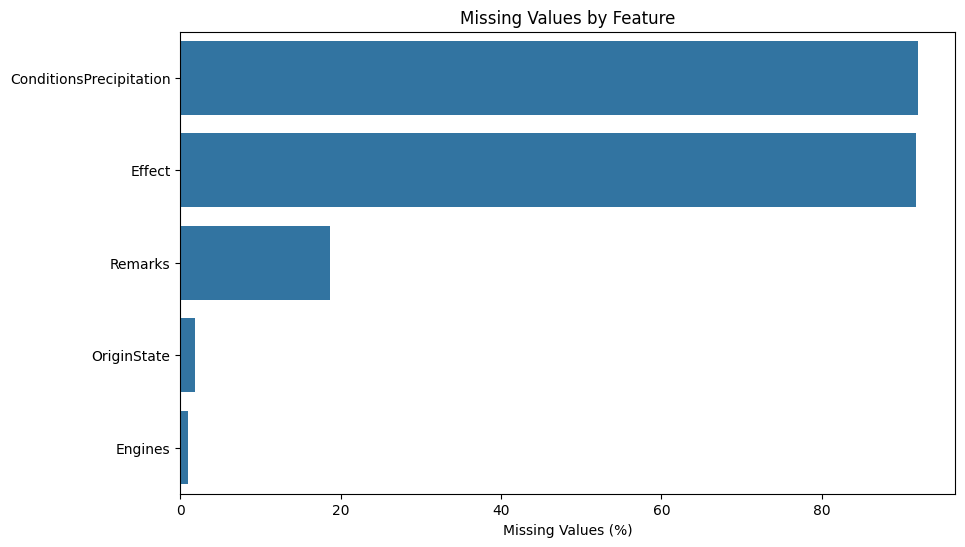

In [9]:
plt.figure(figsize=(10, 6))

missing_plot = missing[missing["MissingPercent"] > 0]

sns.barplot(
    data=missing_plot,
    x="MissingPercent",
    y="Feature"
)

plt.title("Missing Values by Feature")
plt.xlabel("Missing Values (%)")
plt.ylabel("")
plt.show()

### Missing Value Handling Strategy

Missing values are handled according to their meaning rather than removing
all incomplete observations.

- ConditionsPrecipitation → "Not Reported"
- Effect → "Not Reported"
- OriginState → "Unknown"
- Engines → treated as missing if invalid and imputed during modeling
- Remarks → retained for descriptive purposes but excluded from the main model

Rows are not removed solely because precipitation or effect information is
missing because doing so would discard more than 90% of the observations.

# Data Cleaning & Feature Engineering

In [10]:
data = df.copy()

In [11]:
data["FlightDate"] = pd.to_datetime(
    data["FlightDate"],
    format="%m/%d/%y %H:%M",
    errors="coerce"
)

data["Year"] = data["FlightDate"].dt.year
data["Month"] = data["FlightDate"].dt.month
data["MonthName"] = data["FlightDate"].dt.month_name()
data["Quarter"] = data["FlightDate"].dt.quarter

In [12]:
data["Cost"] = (
    data["Cost"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

data["Cost"] = pd.to_numeric(data["Cost"], errors="coerce")

In [13]:
data["EnginesNumeric"] = pd.to_numeric(
    data["Engines"],
    errors="coerce"
)

In [14]:
data["ConditionsPrecipitation"] = (
    data["ConditionsPrecipitation"]
    .fillna("Not Reported")
)

data["Effect"] = data["Effect"].fillna("Not Reported")

data["OriginState"] = data["OriginState"].fillna("Unknown")

In [15]:
data["DamageTarget"] = (
    data["Damage"]
    .map({
        "No damage": 0,
        "Caused damage": 1
    })
)

In [16]:
data[[
    "FlightDate",
    "Year",
    "Month",
    "Cost",
    "EnginesNumeric",
    "DamageTarget"
]].head()

,FlightDate,Year,Month,Cost,EnginesNumeric,DamageTarget
0,2000-11-23,2000,11,30736,2.0,1
1,2001-07-25,2001,7,0,2.0,1
2,2001-09-14,2001,9,0,2.0,0
3,2002-09-05,2002,9,0,2.0,0
4,2003-06-23,2003,6,0,2.0,0


In [17]:
data["FlightDate"].min(), data["FlightDate"].max()

(Timestamp('2000-01-02 00:00:00'), Timestamp('2011-12-31 00:00:00'))

# Target Analysis

## 3. Target Distribution

Aircraft damage is the main outcome used for predictive modeling.
Because damage events are substantially less frequent than non-damage events,
class imbalance must be considered during model training and evaluation.

In [18]:
damage_summary = (
    data["Damage"]
    .value_counts()
    .rename_axis("Damage")
    .reset_index(name="Count")
)

damage_summary["Percentage"] = (
    damage_summary["Count"] / len(data) * 100
).round(2)

damage_summary

,Damage,Count,Percentage
0,No damage,22975,90.35
1,Caused damage,2454,9.65


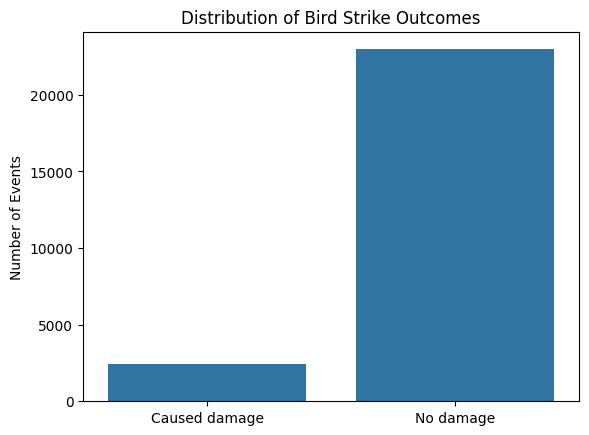

In [19]:
sns.countplot(data=data, x="Damage")

plt.title("Distribution of Bird Strike Outcomes")
plt.xlabel("")
plt.ylabel("Number of Events")
plt.show()

Because only 9.65% of events resulted in aircraft damage, accuracy alone is not an appropriate evaluation metric.

## 4. Pola Temporal

Tahap pertama analisis bahaya mengkaji kapan kejadian *bird strike* paling sering tercatat dan apakah tingkat keparahan kerusakan mengikuti pola yang sama.


### Annual Trend

In [20]:
yearly = (
    data.groupby("Year")
    .agg(
        Incidents=("RecordID", "count"),
        DamageEvents=("DamageTarget", "sum"),
        DamageRate=("DamageTarget", "mean")
    )
    .reset_index()
)

yearly["DamageRate"] *= 100

yearly

,Year,Incidents,DamageEvents,DamageRate
0,2000,1367,196,14.337966
1,2001,1230,123,10.000000
2,2002,1681,186,11.064842
3,2003,1568,201,12.818878
4,2004,1692,184,10.874704
5,2005,1853,180,9.713977
6,2006,2159,232,10.745716
7,2007,2301,217,9.430682
8,2008,2258,218,9.654562
9,2009,3247,250,7.699415


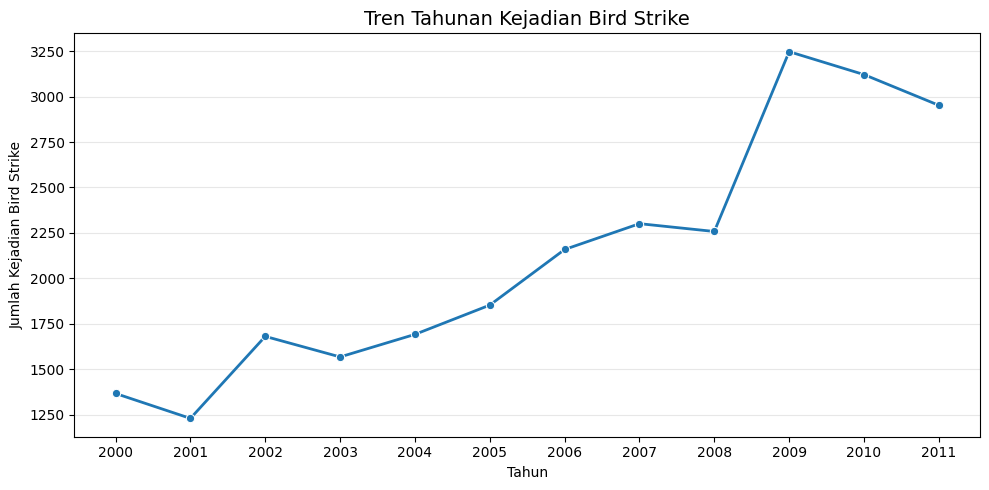

In [21]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly,
    x="Year",
    y="Incidents",
    marker="o",
    linewidth=2
)

plt.title("Tren Tahunan Kejadian Bird Strike", fontsize=14)
plt.xlabel("Tahun")
plt.ylabel("Jumlah Kejadian Bird Strike")

plt.xticks(yearly["Year"])
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Membuat ringkasan kejadian bird strike bulanan

monthly = (
    data.groupby(["Month", "MonthName"])
    .agg(
        Incidents=("RecordID", "count"),
        DamageEvents=("DamageTarget", "sum"),
        DamageRate=("DamageTarget", "mean")
    )
    .reset_index()
    .sort_values("Month")
)

# Mengubah proporsi menjadi persen
monthly["DamageRate"] = monthly["DamageRate"] * 100

monthly

,Month,MonthName,Incidents,DamageEvents,DamageRate
0,1,January,937,140,14.941302
1,2,February,772,110,14.248705
2,3,March,1233,215,17.437145
3,4,April,1828,223,12.199125
4,5,May,2318,182,7.851596
5,6,June,2078,161,7.747834
6,7,July,3278,186,5.674192
7,8,August,3710,233,6.280323
8,9,September,3417,277,8.106526
9,10,October,3038,288,9.479921


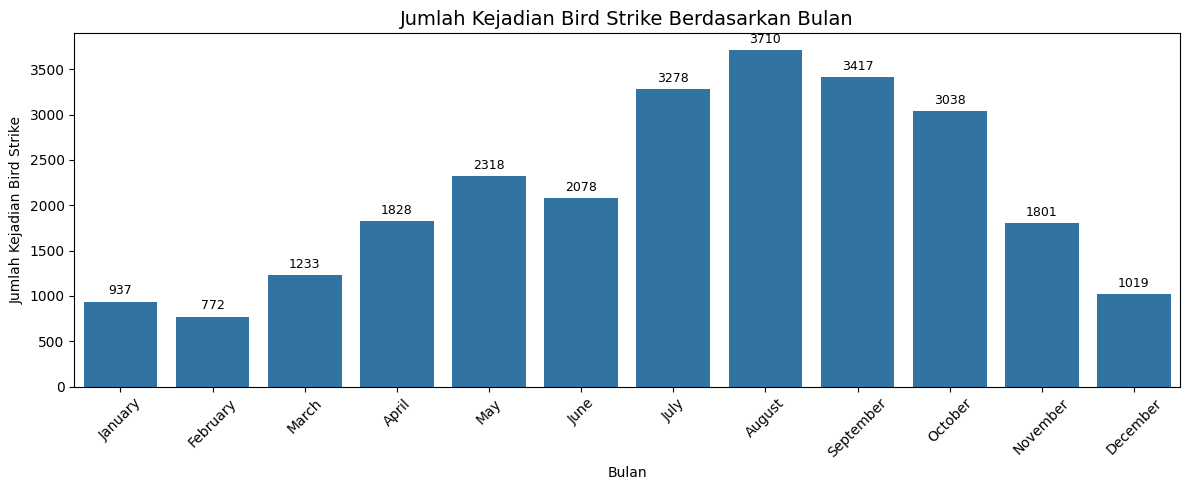

In [23]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly["MonthName"] = pd.Categorical(
    monthly["MonthName"],
    categories=month_order,
    ordered=True
)

monthly = monthly.sort_values("Month")

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=monthly,
    x="MonthName",
    y="Incidents"
)

plt.title("Jumlah Kejadian Bird Strike Berdasarkan Bulan", fontsize=14)
plt.xlabel("Bulan")
plt.ylabel("Jumlah Kejadian Bird Strike")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

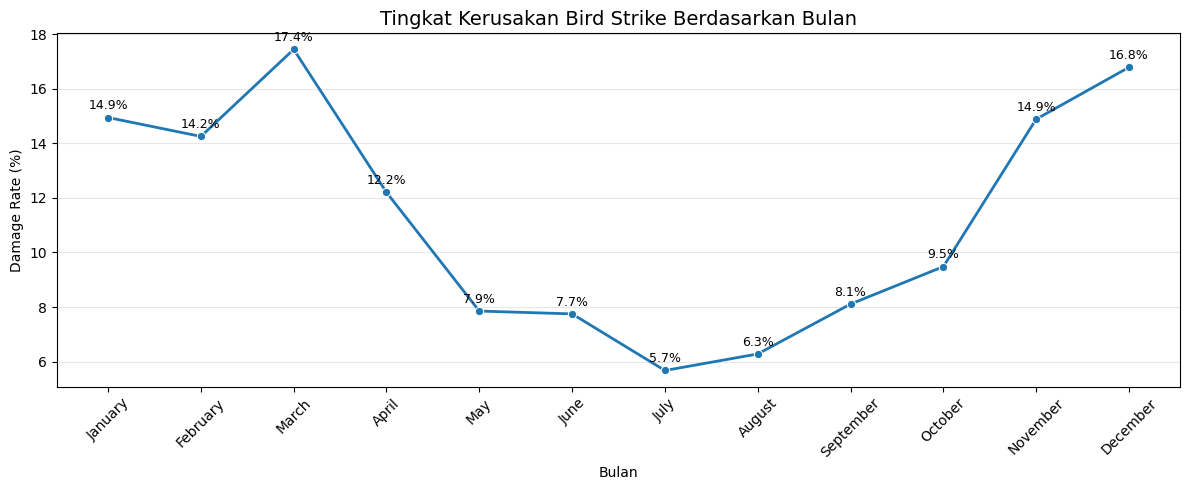

In [24]:
plt.figure(figsize=(12, 5))

ax = sns.lineplot(
    data=monthly,
    x="MonthName",
    y="DamageRate",
    marker="o",
    linewidth=2
)

for i, row in monthly.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["DamageRate"] + 0.3,
        f"{row['DamageRate']:.1f}%",
        ha="center",
        fontsize=9
    )

plt.title("Tingkat Kerusakan Bird Strike Berdasarkan Bulan", fontsize=14)
plt.xlabel("Bulan")
plt.ylabel("Damage Rate (%)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
data["FlightDate"] = pd.to_datetime(
    data["FlightDate"],
    format="%m/%d/%y %H:%M",
    errors="coerce"
)

data["Year"] = data["FlightDate"].dt.year
data["Month"] = data["FlightDate"].dt.month
data["MonthName"] = data["FlightDate"].dt.month_name()
data["Quarter"] = data["FlightDate"].dt.quarter

## 5. Analisis Risiko Operasional Penerbangan

Analisis berikut mengevaluasi distribusi kejadian *bird strike* berdasarkan fase penerbangan dan ketinggian pesawat. Frekuensi kejadian dan tingkat kerusakan dianalisis secara terpisah untuk membedakan kondisi yang sering mengalami *bird strike* dengan kondisi yang memiliki proporsi kerusakan lebih tinggi.


In [26]:
phase_summary = (
    data.groupby("FlightPhase")
    .agg(
        Incidents=("RecordID", "count"),
        DamageEvents=("DamageTarget", "sum"),
        DamageRate=("DamageTarget", "mean")
    )
    .reset_index()
)

# Ubah damage rate menjadi persen
phase_summary["DamageRate"] = (
    phase_summary["DamageRate"] * 100
)

# Urutkan berdasarkan jumlah kejadian
phase_summary = phase_summary.sort_values(
    "Incidents",
    ascending=False
)

phase_summary

,FlightPhase,Incidents,DamageEvents,DamageRate
0,Approach,10382,985,9.487575
3,Landing Roll,5047,236,4.676045
5,Take-off run,4711,376,7.981320
1,Climb,4429,694,15.669451
2,Descent,776,157,20.231959
6,Taxi,74,4,5.405405
4,Parked,10,2,20.000000


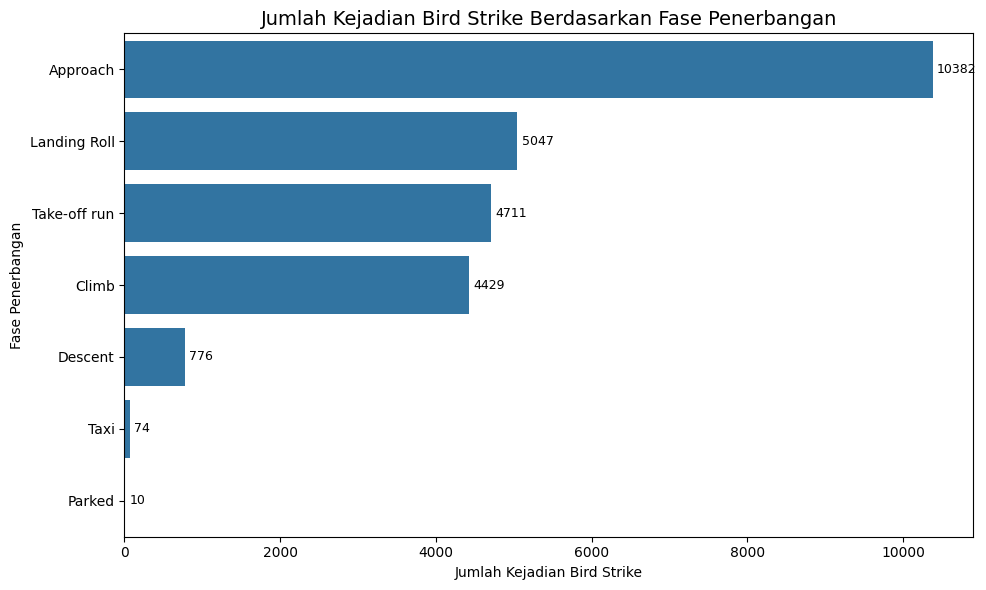

In [27]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=phase_summary,
    x="Incidents",
    y="FlightPhase"
)

plt.title(
    "Jumlah Kejadian Bird Strike Berdasarkan Fase Penerbangan",
    fontsize=14
)
plt.xlabel("Jumlah Kejadian Bird Strike")
plt.ylabel("Fase Penerbangan")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

Distribusi kejadian menunjukkan bahwa *bird strike* tidak tercatat dengan frekuensi yang sama pada setiap fase penerbangan. Fase dengan jumlah kejadian tertinggi menunjukkan kondisi operasional yang paling sering muncul dalam catatan *bird strike* pada dataset.

Namun, jumlah kejadian yang tinggi belum tentu menunjukkan tingkat dampak kerusakan yang paling besar. Oleh karena itu, analisis selanjutnya membandingkan proporsi kejadian yang menyebabkan kerusakan pada setiap fase penerbangan.


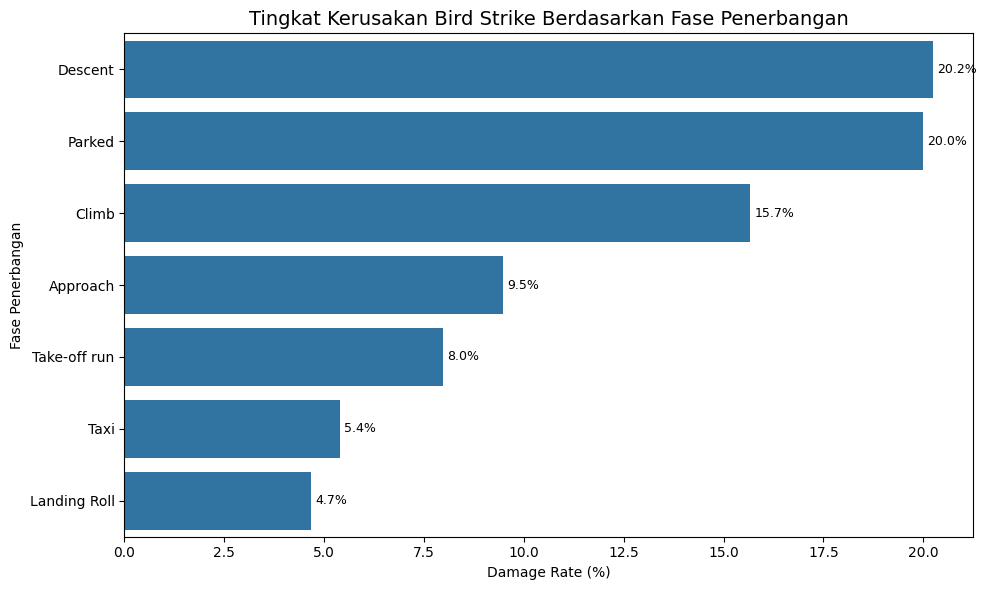

In [28]:
phase_damage = phase_summary.sort_values(
    "DamageRate",
    ascending=False
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=phase_damage,
    x="DamageRate",
    y="FlightPhase"
)

plt.title(
    "Tingkat Kerusakan Bird Strike Berdasarkan Fase Penerbangan",
    fontsize=14
)
plt.xlabel("Damage Rate (%)")
plt.ylabel("Fase Penerbangan")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [29]:
phase_damage[
    [
        "FlightPhase",
        "Incidents",
        "DamageEvents",
        "DamageRate"
    ]
].reset_index(drop=True)

,FlightPhase,Incidents,DamageEvents,DamageRate
0,Descent,776,157,20.231959
1,Parked,10,2,20.000000
2,Climb,4429,694,15.669451
3,Approach,10382,985,9.487575
4,Take-off run,4711,376,7.981320
5,Taxi,74,4,5.405405
6,Landing Roll,5047,236,4.676045


Perbandingan antara jumlah kejadian dan *damage rate* menunjukkan bahwa frekuensi dan tingkat keparahan *bird strike* tidak selalu memiliki pola yang sama. Fase penerbangan dengan jumlah kejadian tertinggi belum tentu memiliki proporsi kerusakan paling besar.

Perbedaan tersebut menunjukkan pentingnya mengevaluasi *bird strike* dari dua perspektif, yaitu frekuensi kejadian sebagai indikator paparan historis dan *damage rate* sebagai indikator tingkat keparahan relatif dari kejadian yang tercatat.


In [30]:
data["Altitude"].describe()

count    25429.000000
mean       799.028432
std       1740.079843
min          0.000000
25%          0.000000
50%         50.000000
75%        700.000000
max      18000.000000
Name: Altitude, dtype: float64

In [31]:
print(
    f"Missing Altitude: "
    f"{data['Altitude'].isna().sum():,}"
)

Missing Altitude: 0


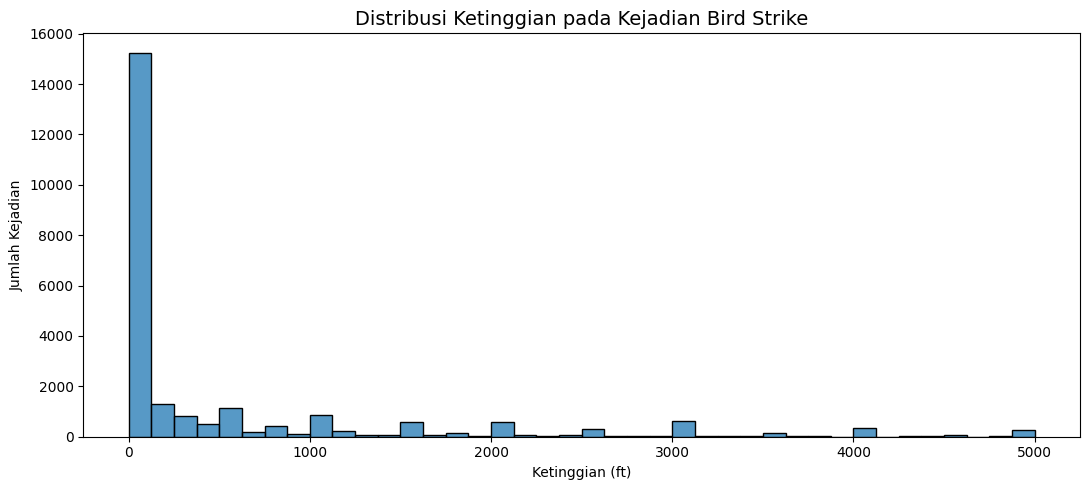

In [32]:
altitude_plot = data[
    data["Altitude"].notna() &
    (data["Altitude"] <= 5000)
].copy()

plt.figure(figsize=(11, 5))

sns.histplot(
    data=altitude_plot,
    x="Altitude",
    bins=40
)

plt.title(
    "Distribusi Ketinggian pada Kejadian Bird Strike",
    fontsize=14
)
plt.xlabel("Ketinggian (ft)")
plt.ylabel("Jumlah Kejadian")

plt.tight_layout()
plt.show()

Visualisasi dibatasi hingga 5.000 ft agar pola pada rentang ketinggian dengan konsentrasi kejadian terbesar dapat terlihat lebih jelas. Pembatasan tersebut hanya diterapkan pada visualisasi dan tidak menghapus observasi dengan ketinggian lebih tinggi dari dataset maupun analisis selanjutnya.


In [33]:
altitude_damage_summary = (
    data.groupby("Damage")
    .agg(
        Events=("RecordID", "count"),
        MedianAltitude=("Altitude", "median"),
        MeanAltitude=("Altitude", "mean")
    )
    .reset_index()
)

altitude_damage_summary

,Damage,Events,MedianAltitude,MeanAltitude
0,Caused damage,2454,300.0,1303.588427
1,No damage,22975,40.0,745.135495


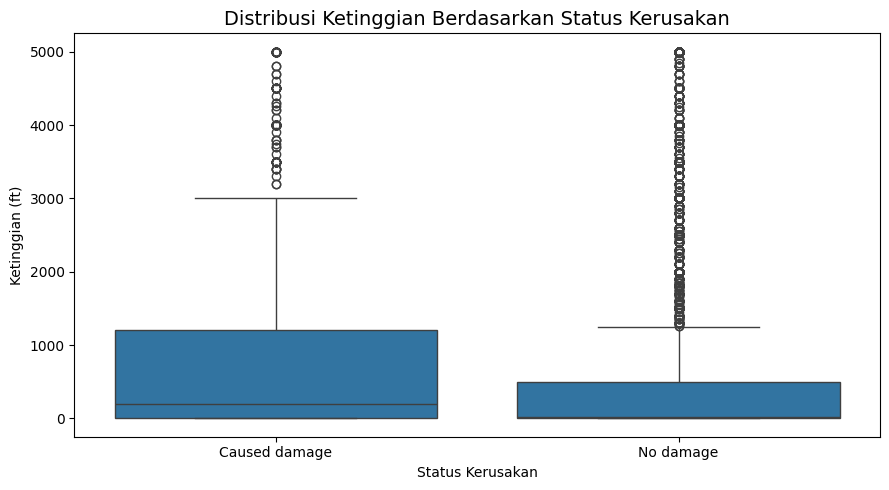

In [34]:
altitude_boxplot = data[
    data["Altitude"].notna() &
    (data["Altitude"] <= 5000)
].copy()

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=altitude_boxplot,
    x="Damage",
    y="Altitude"
)

plt.title(
    "Distribusi Ketinggian Berdasarkan Status Kerusakan",
    fontsize=14
)
plt.xlabel("Status Kerusakan")
plt.ylabel("Ketinggian (ft)")

plt.tight_layout()
plt.show()

Distribusi ketinggian menunjukkan adanya perbedaan karakteristik antara kejadian yang menyebabkan kerusakan dan kejadian tanpa kerusakan. Perbedaan tersebut selanjutnya perlu dievaluasi bersama faktor operasional lainnya karena ketinggian juga berkaitan dengan fase penerbangan.

Oleh karena itu, hubungan antara ketinggian dan kerusakan belum dapat diinterpretasikan sebagai hubungan sebab-akibat hanya berdasarkan visualisasi ini.


In [35]:
altitude_risk = (
    data.groupby("AltitudeBin")
    .agg(
        Incidents=("RecordID", "count"),
        DamageEvents=("DamageTarget", "sum"),
        DamageRate=("DamageTarget", "mean")
    )
    .reset_index()
)

altitude_risk["DamageRate"] = (
    altitude_risk["DamageRate"] * 100
)

altitude_risk

,AltitudeBin,Incidents,DamageEvents,DamageRate
0,"(-1, 0]",9843,619,6.288733
1,"(0, 10]",1353,151,11.160384
2,"(10, 30]",1094,80,7.312614
3,"(100, 200]",1296,125,9.645062
4,"(1000, 2000]",1807,294,16.270061
5,"(200, 400]",1299,150,11.547344
6,"(2000, 3000]",1175,171,14.553191
7,"(30, 50]",1383,111,8.026030
8,"(3000, 5000]",1006,130,12.922465
9,"(400, 600]",1160,120,10.344828


In [36]:
print(
    altitude_risk["AltitudeBin"].tolist()
)

['(-1, 0]', '(0, 10]', '(10, 30]', '(100, 200]', '(1000, 2000]', '(200, 400]', '(2000, 3000]', '(30, 50]', '(3000, 5000]', '(400, 600]', '(50, 100]', '(5000, 18000]', '(600, 1000]']


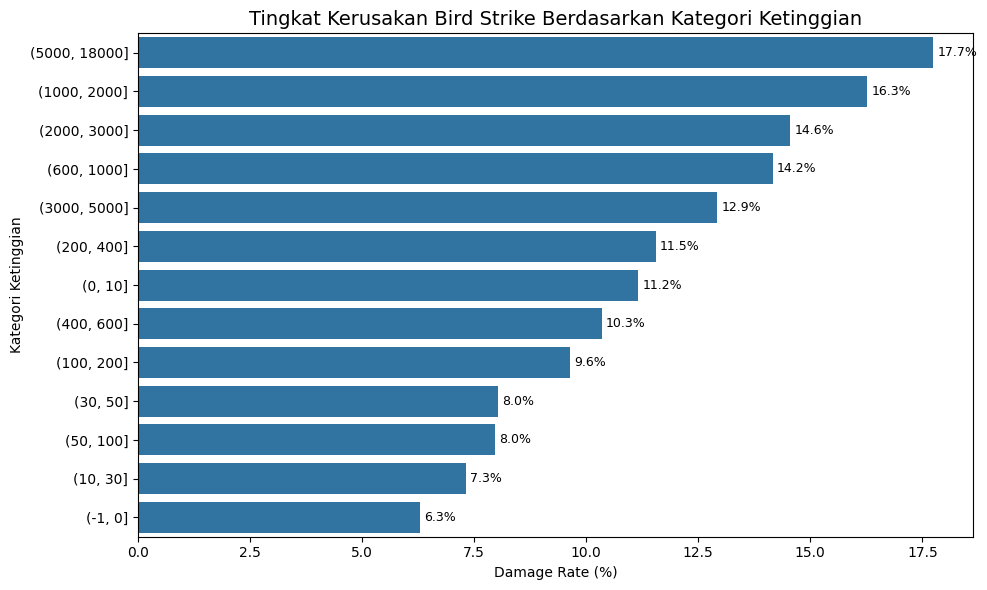

In [37]:
altitude_risk_plot = altitude_risk.sort_values(
    "DamageRate",
    ascending=False
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=altitude_risk_plot,
    x="DamageRate",
    y="AltitudeBin"
)

plt.title(
    "Tingkat Kerusakan Bird Strike Berdasarkan Kategori Ketinggian",
    fontsize=14
)
plt.xlabel("Damage Rate (%)")
plt.ylabel("Kategori Ketinggian")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [38]:
altitude_risk_plot[
    [
        "AltitudeBin",
        "Incidents",
        "DamageEvents",
        "DamageRate"
    ]
].reset_index(drop=True)

,AltitudeBin,Incidents,DamageEvents,DamageRate
0,"(5000, 18000]",885,157,17.740113
1,"(1000, 2000]",1807,294,16.270061
2,"(2000, 3000]",1175,171,14.553191
3,"(600, 1000]",1560,221,14.166667
4,"(3000, 5000]",1006,130,12.922465
5,"(200, 400]",1299,150,11.547344
6,"(0, 10]",1353,151,11.160384
7,"(400, 600]",1160,120,10.344828
8,"(100, 200]",1296,125,9.645062
9,"(30, 50]",1383,111,8.026030


# Wildlife Hazard Analysis

## 6. Analisis Karakteristik Wildlife Hazard

Karakteristik satwa merupakan salah satu komponen penting dalam evaluasi *wildlife hazard*. Analisis berikut mengevaluasi hubungan antara ukuran satwa, jumlah satwa yang terlibat, serta spesies dengan frekuensi dan tingkat kerusakan kejadian *bird strike*.


In [39]:
wildlife_size = (
    data.groupby("WildlifeSize")
    .agg(
        Incidents=("RecordID", "count"),
        DamageEvents=("DamageTarget", "sum"),
        DamageRate=("DamageTarget", "mean")
    )
    .reset_index()
)

wildlife_size["DamageRate"] = (
    wildlife_size["DamageRate"] * 100
)

wildlife_size = wildlife_size.sort_values(
    "DamageRate",
    ascending=False
)

wildlife_size

,WildlifeSize,Incidents,DamageEvents,DamageRate
0,Large,2080,928,44.615385
1,Medium,5937,924,15.563416
2,Small,17412,602,3.457386


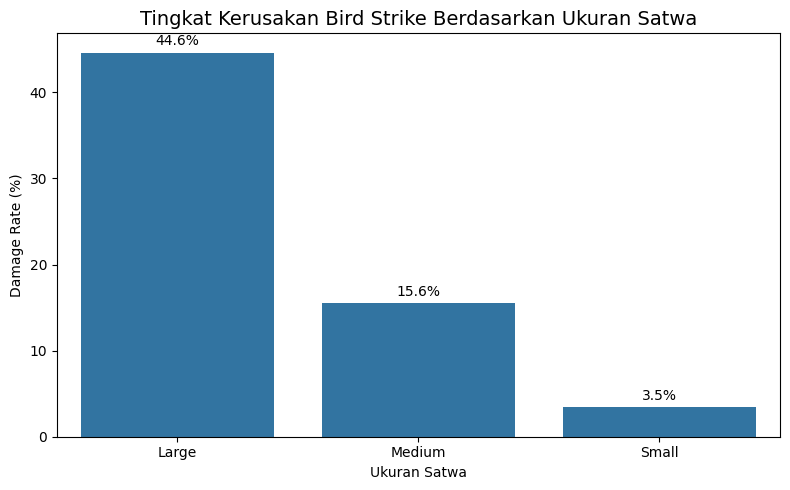

In [40]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=wildlife_size,
    x="WildlifeSize",
    y="DamageRate"
)

plt.title(
    "Tingkat Kerusakan Bird Strike Berdasarkan Ukuran Satwa",
    fontsize=14
)
plt.xlabel("Ukuran Satwa")
plt.ylabel("Damage Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [41]:
wildlife_size[
    [
        "WildlifeSize",
        "Incidents",
        "DamageEvents",
        "DamageRate"
    ]
].reset_index(drop=True)

,WildlifeSize,Incidents,DamageEvents,DamageRate
0,Large,2080,928,44.615385
1,Medium,5937,924,15.563416
2,Small,17412,602,3.457386


## Jumlah Satwa yang Tertabrak

In [42]:
number_struck_risk = (
    data.groupby("NumberStruck")
    .agg(
        Incidents=("RecordID", "count"),
        DamageEvents=("DamageTarget", "sum"),
        DamageRate=("DamageTarget", "mean")
    )
    .reset_index()
)

number_struck_risk["DamageRate"] = (
    number_struck_risk["DamageRate"] * 100
)

number_order = [
    "1",
    "2 to 10",
    "11 to 100",
    "Over 100"
]

number_struck_risk["NumberStruck"] = pd.Categorical(
    number_struck_risk["NumberStruck"],
    categories=number_order,
    ordered=True
)

number_struck_risk = number_struck_risk.sort_values(
    "NumberStruck"
)

number_struck_risk

,NumberStruck,Incidents,DamageEvents,DamageRate
0,1,20790,1789,8.605099
2,2 to 10,4319,584,13.521649
1,11 to 100,312,77,24.679487
3,Over 100,8,4,50.000000


## Damage Rate Berdasarkan Jumlah Satwa yang Tertabrak

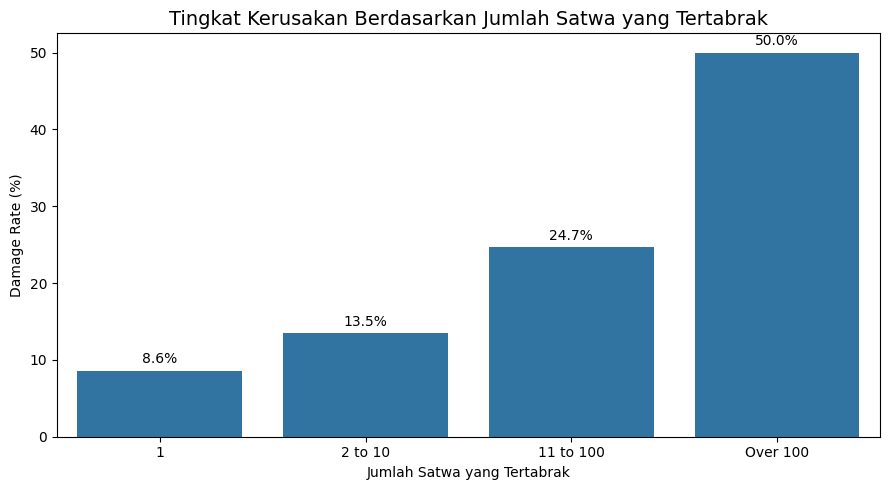

In [43]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=number_struck_risk,
    x="NumberStruck",
    y="DamageRate"
)

plt.title(
    "Tingkat Kerusakan Berdasarkan Jumlah Satwa yang Tertabrak",
    fontsize=14
)
plt.xlabel("Jumlah Satwa yang Tertabrak")
plt.ylabel("Damage Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [44]:
number_struck_risk[
    [
        "NumberStruck",
        "Incidents",
        "DamageEvents",
        "DamageRate"
    ]
].reset_index(drop=True)

,NumberStruck,Incidents,DamageEvents,DamageRate
0,1,20790,1789,8.605099
1,2 to 10,4319,584,13.521649
2,11 to 100,312,77,24.679487
3,Over 100,8,4,50.000000


Tingkat kerusakan menunjukkan kecenderungan meningkat seiring bertambahnya jumlah satwa yang terlibat dalam kejadian *bird strike*. Pola ini menunjukkan bahwa kejadian yang melibatkan lebih dari satu satwa dapat memiliki konsekuensi yang lebih berat dibandingkan kejadian yang hanya melibatkan satu satwa.

Namun, kategori dengan jumlah observasi yang sangat sedikit perlu diinterpretasikan secara hati-hati. Sebagai contoh, persentase kerusakan yang tinggi pada kategori dengan lebih dari 100 satwa belum tentu mencerminkan pola yang stabil apabila jumlah kasusnya sangat terbatas.


## Top 15 Spesies dengan Kejadian Bird Strike Terbanyak

In [45]:
top_species = (
    data["WildlifeSpecies"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_species.columns = [
    "WildlifeSpecies",
    "Incidents"
]

top_species

,WildlifeSpecies,Incidents
0,Unknown bird - small,10436
1,Unknown bird - medium,4297
2,Mourning dove,897
3,European starling,885
4,Unknown bird - large,793
5,Rock pigeon,592
6,Barn swallow,579
7,Killdeer,470
8,American kestrel,444
9,Red-tailed hawk,410


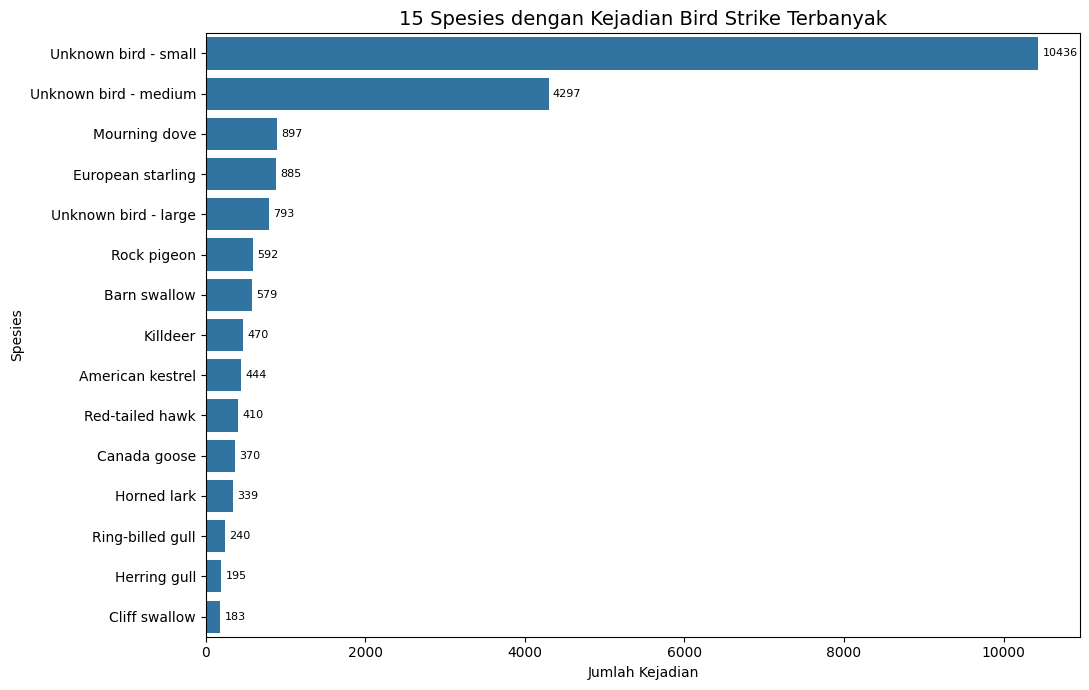

In [46]:
plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=top_species,
    x="Incidents",
    y="WildlifeSpecies"
)

plt.title(
    "15 Spesies dengan Kejadian Bird Strike Terbanyak",
    fontsize=14
)
plt.xlabel("Jumlah Kejadian")
plt.ylabel("Spesies")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

Distribusi spesies menunjukkan bahwa kejadian *bird strike* tidak tersebar secara merata pada seluruh jenis satwa. Beberapa kelompok spesies memiliki jumlah kejadian tercatat yang jauh lebih tinggi dibandingkan kelompok lainnya.

Namun, tingginya jumlah kejadian belum tentu menunjukkan bahwa spesies tersebut memiliki tingkat kerusakan paling besar. Oleh karena itu, analisis berikutnya membandingkan *damage rate* antarspesies dengan mempertimbangkan jumlah minimum observasi.


### Damage Rate Berdasarkan Spesies

In [47]:
species_risk = (
    data.groupby("WildlifeSpecies")
    .agg(
        Incidents=("RecordID", "count"),
        DamageEvents=("DamageTarget", "sum"),
        DamageRate=("DamageTarget", "mean")
    )
    .reset_index()
)

species_risk["DamageRate"] = (
    species_risk["DamageRate"] * 100
)

species_risk_filtered = species_risk[
    species_risk["Incidents"] >= 30
].copy()

species_risk_filtered = (
    species_risk_filtered
    .sort_values(
        "DamageRate",
        ascending=False
    )
)

species_risk_filtered.head(15)

,WildlifeSpecies,Incidents,DamageEvents,DamageRate
316,White-tailed deer,85,79,92.941176
273,Snow goose,36,27,75.000000
30,Black vulture,36,24,66.666667
66,Canada goose,370,210,56.756757
293,Turkey vulture,178,95,53.370787
200,Northern pintail,59,31,52.542373
21,Bald eagle,52,25,48.076923
260,Sandhill crane,39,17,43.589744
209,Osprey,61,24,39.344262
134,Great blue heron,81,31,38.271605


### Top 15 Spesies dengan Damage Rate Tertinggi

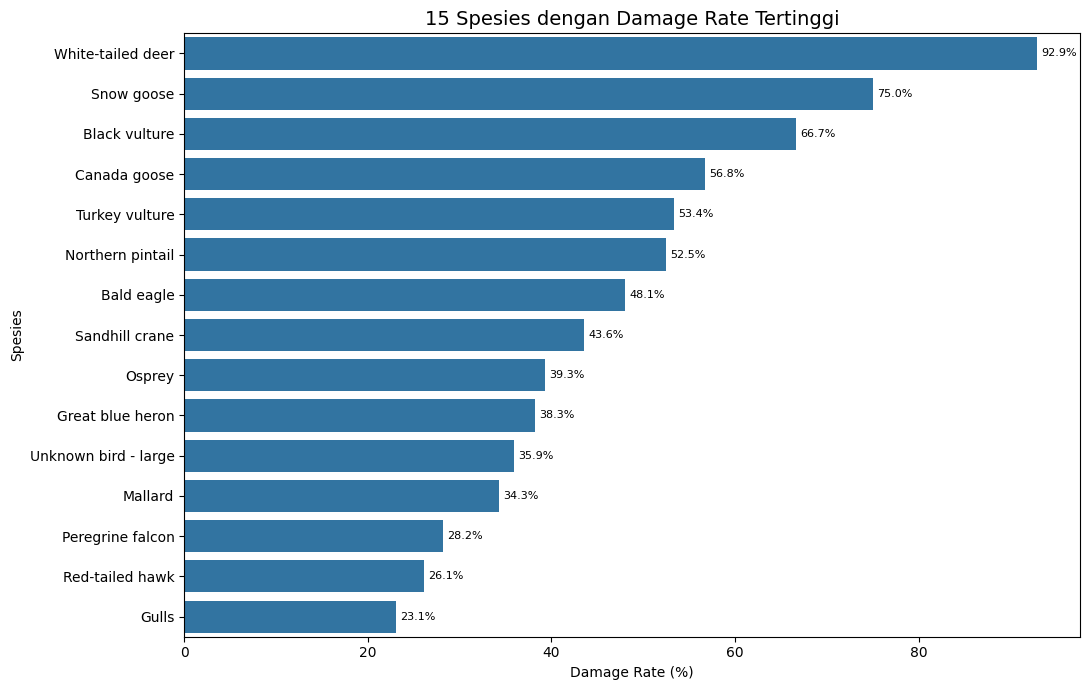

In [48]:
top_species_damage = (
    species_risk_filtered
    .head(15)
    .copy()
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=top_species_damage,
    x="DamageRate",
    y="WildlifeSpecies"
)

plt.title(
    "15 Spesies dengan Damage Rate Tertinggi",
    fontsize=14
)
plt.xlabel("Damage Rate (%)")
plt.ylabel("Spesies")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [49]:
top_species_damage[
    [
        "WildlifeSpecies",
        "Incidents",
        "DamageEvents",
        "DamageRate"
    ]
].reset_index(drop=True)

,WildlifeSpecies,Incidents,DamageEvents,DamageRate
0,White-tailed deer,85,79,92.941176
1,Snow goose,36,27,75.000000
2,Black vulture,36,24,66.666667
3,Canada goose,370,210,56.756757
4,Turkey vulture,178,95,53.370787
5,Northern pintail,59,31,52.542373
6,Bald eagle,52,25,48.076923
7,Sandhill crane,39,17,43.589744
8,Osprey,61,24,39.344262
9,Great blue heron,81,31,38.271605


Beberapa spesies menunjukkan proporsi kejadian yang menyebabkan kerusakan lebih tinggi dibandingkan spesies lainnya. Analisis ini hanya memasukkan spesies dengan sedikitnya 30 kejadian agar persentase kerusakan tidak terlalu dipengaruhi oleh kategori dengan jumlah observasi yang sangat kecil.

Perbedaan *damage rate* antarspesies dapat berkaitan dengan karakteristik fisik satwa, termasuk ukuran tubuh, tetapi hubungan tersebut belum dapat dianggap sebagai hubungan sebab-akibat tanpa mempertimbangkan faktor operasional lainnya.


## 7. Analisis Faktor Pesawat dan Operasional

Selain karakteristik satwa, konsekuensi *bird strike* dapat berkaitan dengan kondisi operasional dan karakteristik pesawat. Analisis berikut mengevaluasi ukuran pesawat, peringatan kepada pilot, serta kondisi langit berdasarkan frekuensi dan proporsi kejadian yang menyebabkan kerusakan.


### Ukuran Pesawat dan Damage Rate

In [50]:
data["IsAircraftLarge?"].value_counts(
    dropna=False
)

IsAircraftLarge?
No     17027
Yes     8402
Name: count, dtype: int64

In [51]:
aircraft_size_risk = (
    data.groupby("IsAircraftLarge?")
    .agg(
        Incidents=("RecordID", "count"),
        DamageEvents=("DamageTarget", "sum"),
        DamageRate=("DamageTarget", "mean")
    )
    .reset_index()
)

aircraft_size_risk["DamageRate"] *= 100

aircraft_size_risk

,IsAircraftLarge?,Incidents,DamageEvents,DamageRate
0,No,17027,1850,10.865097
1,Yes,8402,604,7.188765


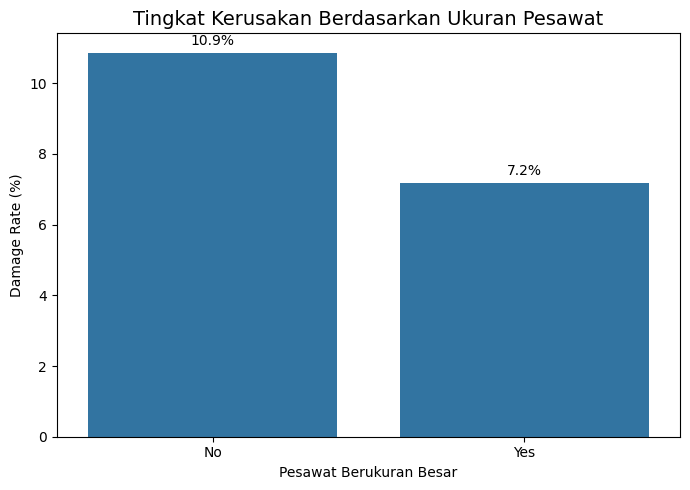

In [52]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=aircraft_size_risk,
    x="IsAircraftLarge?",
    y="DamageRate"
)

plt.title(
    "Tingkat Kerusakan Berdasarkan Ukuran Pesawat",
    fontsize=14
)
plt.xlabel("Pesawat Berukuran Besar")
plt.ylabel("Damage Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Pilot Warning dan Damage Rate

In [53]:
data["PilotWarned"].value_counts(
    dropna=False
)

PilotWarned
N    14567
Y    10862
Name: count, dtype: int64

In [54]:
pilot_warning_risk = (
    data.groupby("PilotWarned")
    .agg(
        Incidents=("RecordID", "count"),
        DamageEvents=("DamageTarget", "sum"),
        DamageRate=("DamageTarget", "mean")
    )
    .reset_index()
)

pilot_warning_risk["DamageRate"] *= 100

pilot_warning_risk

,PilotWarned,Incidents,DamageEvents,DamageRate
0,N,14567,1532,10.516922
1,Y,10862,922,8.488308


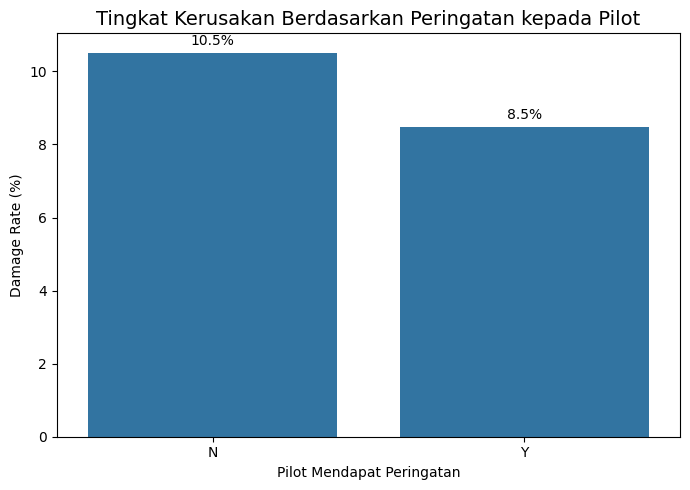

In [55]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=pilot_warning_risk,
    x="PilotWarned",
    y="DamageRate"
)

plt.title(
    "Tingkat Kerusakan Berdasarkan Peringatan kepada Pilot",
    fontsize=14
)
plt.xlabel("Pilot Mendapat Peringatan")
plt.ylabel("Damage Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

Terdapat perbedaan damage rate antara kejadian dengan dan tanpa peringatan kepada pilot.

### Kondisi Langit dan Damage Rate

In [56]:
sky_risk = (
    data.groupby("ConditionsSky")
    .agg(
        Incidents=("RecordID", "count"),
        DamageEvents=("DamageTarget", "sum"),
        DamageRate=("DamageTarget", "mean")
    )
    .reset_index()
)

sky_risk["DamageRate"] *= 100

sky_risk = sky_risk.sort_values(
    "DamageRate",
    ascending=False
)

sky_risk

,ConditionsSky,Incidents,DamageEvents,DamageRate
1,Overcast,4195,444,10.584029
0,No Cloud,12575,1226,9.749503
2,Some Cloud,8659,784,9.054163


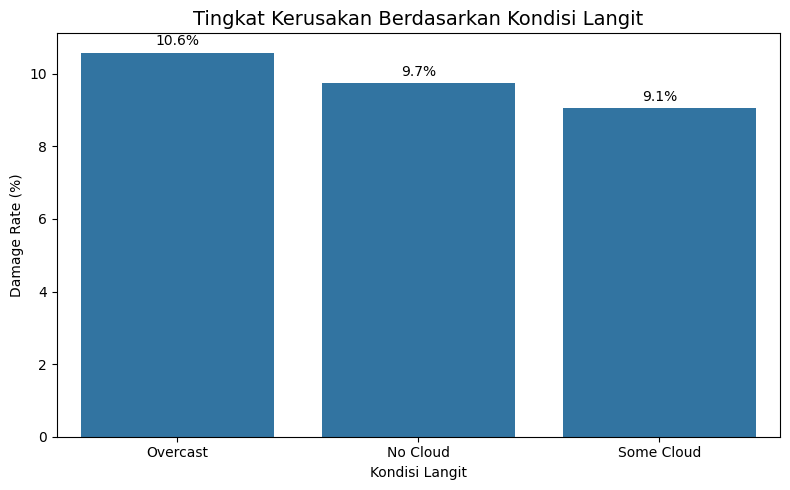

In [57]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=sky_risk,
    x="ConditionsSky",
    y="DamageRate"
)

plt.title(
    "Tingkat Kerusakan Berdasarkan Kondisi Langit",
    fontsize=14
)
plt.xlabel("Kondisi Langit")
plt.ylabel("Damage Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

## 8. Analisis Dampak Kejadian

Selain status kerusakan pesawat, kejadian *bird strike* juga dapat menimbulkan dampak operasional, biaya, dan cedera. Variabel pada bagian ini digunakan untuk memahami konsekuensi kejadian, tetapi tidak digunakan sebagai prediktor utama dalam model kerusakan karena sebagian merupakan informasi yang diketahui setelah kejadian terjadi.


### Dampak Operasional Bird Strike

In [58]:
data["Effect"].value_counts(dropna=False)

Effect
Not Reported             23351
Precautionary Landing     1121
Aborted Take-off           479
Other                      390
Engine Shut Down            88
Name: count, dtype: int64

In [59]:
effect_summary = (
    data["Effect"]
    .fillna("Not Reported")
    .value_counts()
    .reset_index()
)

effect_summary.columns = [
    "Effect",
    "Incidents"
]

effect_summary

,Effect,Incidents
0,Not Reported,23351
1,Precautionary Landing,1121
2,Aborted Take-off,479
3,Other,390
4,Engine Shut Down,88


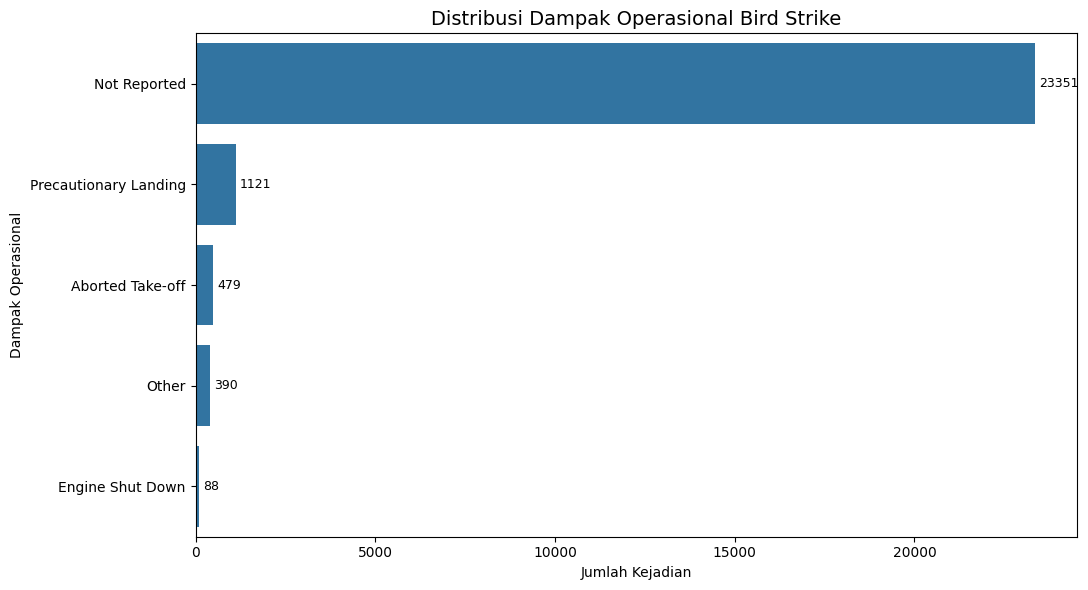

In [60]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=effect_summary,
    x="Incidents",
    y="Effect"
)

plt.title(
    "Distribusi Dampak Operasional Bird Strike",
    fontsize=14
)
plt.xlabel("Jumlah Kejadian")
plt.ylabel("Dampak Operasional")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

Sebagian besar informasi mengenai dampak operasional tidak tercatat secara lengkap pada dataset. Oleh karena itu, distribusi kategori *Effect* lebih tepat digunakan sebagai gambaran konsekuensi yang terdokumentasi, bukan sebagai representasi lengkap seluruh dampak operasional akibat *bird strike*.

Kategori seperti *precautionary landing*, *aborted take-off*, dan *engine shutdown* menunjukkan bahwa sebagian kejadian dapat memengaruhi operasi penerbangan secara langsung.


### Analisis Biaya Kerugian

In [61]:
data["Cost"].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    2.542900e+04
mean     5.566368e+03
std      1.222388e+05
min      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      0.000000e+00
95%      0.000000e+00
99%      6.009504e+04
max      1.239775e+07
Name: Cost, dtype: float64

In [62]:
cost_summary = pd.DataFrame({
    "Metric": [
        "Total kejadian",
        "Kejadian dengan biaya > 0",
        "Total biaya tercatat",
        "Median biaya positif",
        "Maksimum biaya"
    ],
    "Value": [
        len(data),
        (data["Cost"] > 0).sum(),
        data["Cost"].sum(),
        data.loc[data["Cost"] > 0, "Cost"].median(),
        data["Cost"].max()
    ]
})

cost_summary

,Metric,Value
0,Total kejadian,25429.0
1,Kejadian dengan biaya > 0,1214.0
2,Total biaya tercatat,141547178.0
3,Median biaya positif,6455.0
4,Maksimum biaya,12397751.0


### Distribusi Biaya Positif

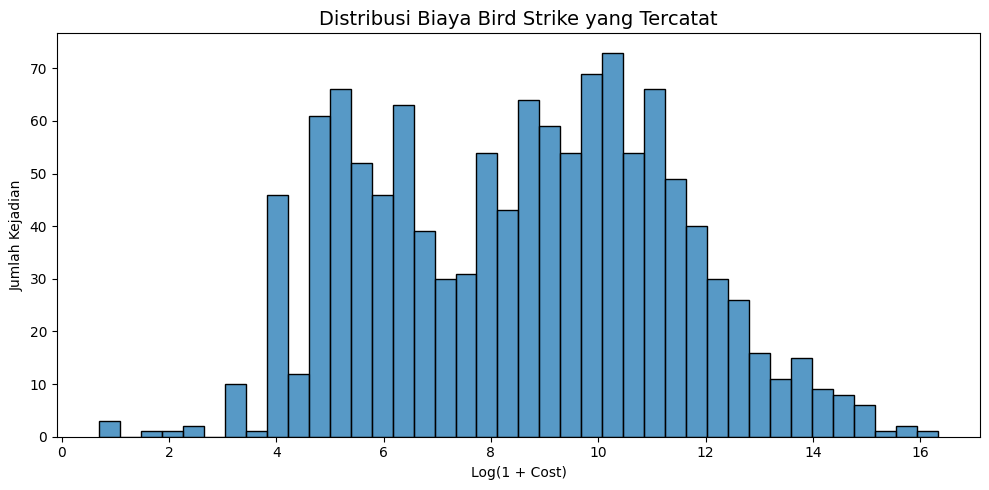

In [63]:
cost_positive = data[
    data["Cost"].notna() &
    (data["Cost"] > 0)
].copy()

cost_positive["LogCost"] = np.log1p(
    cost_positive["Cost"]
)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=cost_positive,
    x="LogCost",
    bins=40
)

plt.title(
    "Distribusi Biaya Bird Strike yang Tercatat",
    fontsize=14
)
plt.xlabel("Log(1 + Cost)")
plt.ylabel("Jumlah Kejadian")

plt.tight_layout()
plt.show()

Distribusi biaya menunjukkan pola yang sangat tidak simetris, dengan sebagian besar kejadian memiliki biaya relatif rendah dan sebagian kecil kejadian memiliki nilai biaya yang sangat tinggi. Oleh karena itu, transformasi log digunakan pada visualisasi agar distribusi biaya dapat diamati dengan lebih jelas.

Nilai biaya juga perlu diinterpretasikan secara hati-hati karena tidak seluruh kejadian memiliki informasi biaya yang lengkap.


In [64]:
cost_damage = (
    data.groupby("Damage")
    .agg(
        Incidents=("RecordID", "count"),
        MedianCost=("Cost", "median"),
        MeanCost=("Cost", "mean"),
        TotalCost=("Cost", "sum")
    )
    .reset_index()
)

cost_damage

,Damage,Incidents,MedianCost,MeanCost,TotalCost
0,Caused damage,2454,0.0,57038.180522,139971695
1,No damage,22975,0.0,68.573798,1575483


In [65]:
cost_positive_damage = (
    data[data["Cost"] > 0]
    .groupby("Damage")
    .agg(
        MedianCost=("Cost", "median"),
        MeanCost=("Cost", "mean")
    )
    .reset_index()
)

cost_positive_damage

,Damage,MedianCost,MeanCost
0,Caused damage,22112.0,169868.561893
1,No damage,271.0,4039.700000


### Analisis Cedera

In [66]:
injury_summary = (
    data["PeopleInjured"]
    .value_counts()
    .sort_index()
    .reset_index()
)

injury_summary.columns = [
    "PeopleInjured",
    "Incidents"
]

injury_summary

,PeopleInjured,Incidents
0,0,25416
1,1,9
2,2,3
3,6,1


In [67]:
injury_events = (
    data["PeopleInjured"] > 0
).sum()

print(
    f"Jumlah kejadian dengan korban cedera: "
    f"{injury_events:,}"
)

Jumlah kejadian dengan korban cedera: 13


### Distribusi Kejadian dengan Cedera

In [68]:
injury_positive = data[
    data["PeopleInjured"] > 0
].copy()

injury_positive["PeopleInjured"].value_counts().sort_index()

PeopleInjured
1    9
2    3
6    1
Name: count, dtype: int64

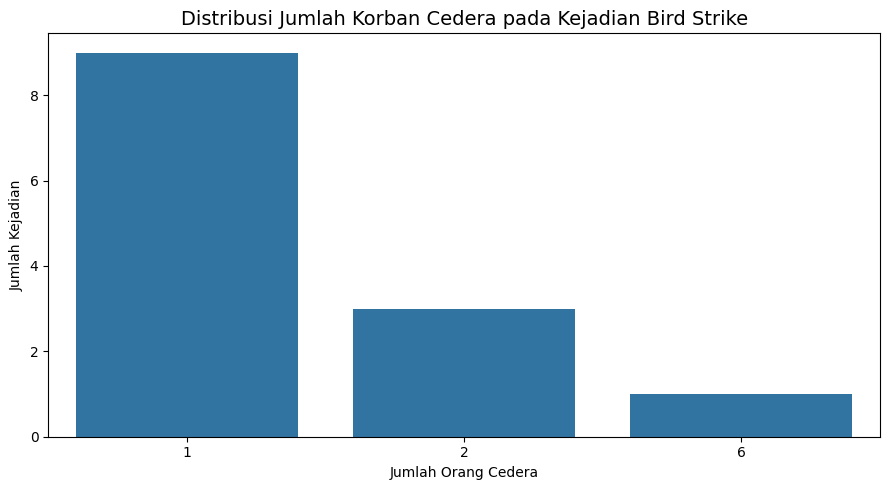

In [69]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=injury_positive,
    x="PeopleInjured"
)

plt.title(
    "Distribusi Jumlah Korban Cedera pada Kejadian Bird Strike",
    fontsize=14
)
plt.xlabel("Jumlah Orang Cedera")
plt.ylabel("Jumlah Kejadian")

plt.tight_layout()
plt.show()

Kejadian *bird strike* yang menyebabkan cedera merupakan bagian yang relatif kecil dari keseluruhan catatan kejadian. Walaupun demikian, keberadaan kasus cedera menunjukkan bahwa konsekuensi *bird strike* tidak hanya terbatas pada kerusakan pesawat, tetapi juga dapat berkaitan dengan keselamatan penumpang maupun awak penerbangan.


## 9. Analisis Statistik Faktor Risiko

Visualisasi sebelumnya menunjukkan adanya perbedaan *damage rate* berdasarkan karakteristik satwa dan kondisi operasional. Pada bagian ini, hubungan tersebut dievaluasi secara statistik untuk mengetahui kekuatan asosiasi antara setiap faktor dengan status kerusakan pesawat.

Variabel kategorikal dianalisis menggunakan uji Chi-Square dan Cramér's V, sedangkan variabel numerik seperti ketinggian dianalisis menggunakan uji Mann–Whitney U karena distribusinya tidak diasumsikan normal.


### Fungsi Cramér's V

In [70]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(
        confusion_matrix
    )[0]

    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    phi2corr = max(
        0,
        phi2 -
        ((k - 1) * (r - 1)) /
        (n - 1)
    )

    rcorr = r - (
        (r - 1) ** 2
    ) / (n - 1)

    kcorr = k - (
        (k - 1) ** 2
    ) / (n - 1)

    denominator = min(
        kcorr - 1,
        rcorr - 1
    )

    if denominator <= 0:
        return np.nan

    return np.sqrt(
        phi2corr / denominator
    )

### Uji Chi-Square dan Cramér's V

In [71]:
categorical_features_test = [
    "WildlifeSize",
    "FlightPhase",
    "NumberStruck",
    "ConditionsSky",
    "PilotWarned",
    "IsAircraftLarge?"
]

statistical_results = []

for feature in categorical_features_test:

    temp = data[
        [feature, "DamageTarget"]
    ].dropna()

    contingency_table = pd.crosstab(
        temp[feature],
        temp["DamageTarget"]
    )

    chi2, p_value, dof, expected = (
        chi2_contingency(
            contingency_table
        )
    )

    v = cramers_v(
        temp[feature],
        temp["DamageTarget"]
    )

    statistical_results.append({
        "Feature": feature,
        "ChiSquare": chi2,
        "DegreesOfFreedom": dof,
        "PValue": p_value,
        "CramersV": v
    })

categorical_stats = pd.DataFrame(
    statistical_results
)

categorical_stats = (
    categorical_stats
    .sort_values(
        "CramersV",
        ascending=False
    )
)

categorical_stats

,Feature,ChiSquare,DegreesOfFreedom,PValue,CramersV
0,WildlifeSize,3920.467845,2,0.000000e+00,0.392556
1,FlightPhase,445.039543,6,5.734582e-93,0.131400
2,NumberStruck,196.053000,3,3.005781e-42,0.087133
5,IsAircraftLarge?,86.785492,1,1.209536e-20,0.058083
4,PilotWarned,29.136039,1,6.747019e-08,0.033264
3,ConditionsSky,7.865937,2,1.958545e-02,0.015188


### Format Hasil Statistik

In [72]:
categorical_stats_display = (
    categorical_stats.copy()
)

categorical_stats_display["ChiSquare"] = (
    categorical_stats_display["ChiSquare"]
    .round(2)
)

categorical_stats_display["PValue"] = (
    categorical_stats_display["PValue"]
    .apply(
        lambda x: f"{x:.4f}"
    )
)

categorical_stats_display["CramersV"] = (
    categorical_stats_display["CramersV"]
    .round(3)
)

categorical_stats_display

,Feature,ChiSquare,DegreesOfFreedom,PValue,CramersV
0,WildlifeSize,3920.47,2,0.0000,0.393
1,FlightPhase,445.04,6,0.0000,0.131
2,NumberStruck,196.05,3,0.0000,0.087
5,IsAircraftLarge?,86.79,1,0.0000,0.058
4,PilotWarned,29.14,1,0.0000,0.033
3,ConditionsSky,7.87,2,0.0196,0.015


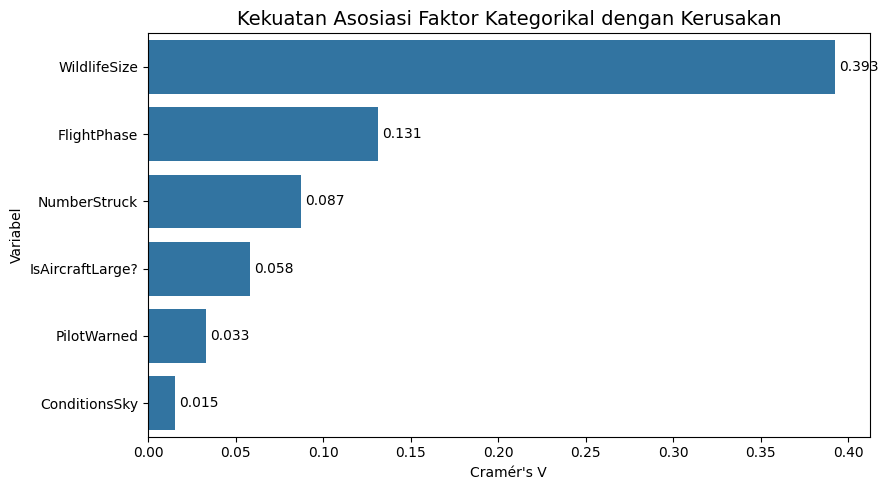

In [73]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=categorical_stats,
    x="CramersV",
    y="Feature"
)

plt.title(
    "Kekuatan Asosiasi Faktor Kategorikal dengan Kerusakan",
    fontsize=14
)
plt.xlabel("Cramér's V")
plt.ylabel("Variabel")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

Nilai Cramér's V digunakan untuk menggambarkan kekuatan asosiasi antara variabel kategorikal dan status kerusakan.

Sebagai panduan umum:

* mendekati 0 menunjukkan asosiasi yang sangat lemah
* sekitar 0,1 menunjukkan asosiasi lemah
* sekitar 0,3 menunjukkan asosiasi sedang
* sekitar 0,5 atau lebih menunjukkan asosiasi yang relatif kuat

Interpretasi tetap perlu mempertimbangkan konteks data, jumlah kategori, serta ukuran sampel. Nilai *p-value* yang kecil menunjukkan adanya asosiasi statistik, tetapi tidak secara otomatis menunjukkan hubungan sebab-akibat.


### Uji Mann–Whitney U untuk Altitude

In [74]:
altitude_damage = (
    data.loc[
        data["DamageTarget"] == 1,
        "Altitude"
    ]
    .dropna()
)

altitude_no_damage = (
    data.loc[
        data["DamageTarget"] == 0,
        "Altitude"
    ]
    .dropna()
)

u_stat, p_value = mannwhitneyu(
    altitude_damage,
    altitude_no_damage,
    alternative="two-sided"
)

print(
    f"Mann-Whitney U : {u_stat:,.0f}"
)

print(
    f"P-value        : {p_value:.6f}"
)

print(
    f"Median altitude - damage    : "
    f"{altitude_damage.median():,.2f} ft"
)

print(
    f"Median altitude - no damage : "
    f"{altitude_no_damage.median():,.2f} ft"
)

Mann-Whitney U : 34,224,070
P-value        : 0.000000
Median altitude - damage    : 300.00 ft
Median altitude - no damage : 40.00 ft


Uji Mann–Whitney U digunakan untuk mengevaluasi apakah distribusi ketinggian berbeda antara kejadian *bird strike* yang menyebabkan kerusakan dan kejadian tanpa kerusakan.

Jika nilai *p-value* lebih kecil dari 0,05, maka terdapat perbedaan distribusi ketinggian yang signifikan secara statistik antara kedua kelompok. Namun, signifikansi statistik tidak menunjukkan bahwa ketinggian merupakan penyebab langsung kerusakan karena faktor lain, seperti fase penerbangan, karakteristik satwa, dan kondisi pesawat, juga dapat berperan.


### Ringkasan Faktor Risiko untuk Tahap Modeling

In [75]:
risk_factor_summary = pd.DataFrame({
    "Feature": [
        "WildlifeSize",
        "WildlifeSpecies",
        "FlightPhase",
        "NumberStruck",
        "Altitude",
        "AltitudeBin",
        "ConditionsSky",
        "PilotWarned",
        "IsAircraftLarge?",
        "Engines",
        "MakeModel",
        "Month"
    ],
    "Type": [
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Numerical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical"
    ],
    "UseInModel": ["Yes"] * 12
})

risk_factor_summary


,Feature,Type,UseInModel
0,WildlifeSize,Categorical,Yes
1,WildlifeSpecies,Categorical,Yes
2,FlightPhase,Categorical,Yes
3,NumberStruck,Categorical,Yes
4,Altitude,Numerical,Yes
5,AltitudeBin,Categorical,Yes
6,ConditionsSky,Categorical,Yes
7,PilotWarned,Categorical,Yes
8,IsAircraftLarge?,Categorical,Yes
9,Engines,Categorical,Yes


## 10. Persiapan Pemodelan Prediktif

Hasil eksplorasi dan analisis statistik menunjukkan bahwa beberapa karakteristik kejadian memiliki hubungan dengan status kerusakan. Tahap berikutnya menggunakan faktor-faktor tersebut untuk membangun model klasifikasi yang memperkirakan probabilitas kerusakan ketika *bird strike* telah terjadi.

Pemodelan tidak menggunakan seluruh variabel yang tersedia. Variabel yang merupakan konsekuensi setelah kejadian, identifier, maupun fitur yang berpotensi menyebabkan *target leakage* dikeluarkan dari model.


### Menentukan Fitur dan Target

In [76]:
features = [
    "FlightPhase",
    "Altitude",
    "AltitudeBin",
    "WildlifeSize",
    "WildlifeSpecies",
    "NumberStruck",
    "ConditionsSky",
    "PilotWarned",
    "IsAircraftLarge?",
    "Engines",
    "MakeModel",
    "Month"
]

target = "DamageTarget"

X = data[features].copy()
y = data[target].copy()

print(f"Jumlah observasi : {len(X):,}")
print(f"Jumlah fitur     : {X.shape[1]}")
print(f"Damage rate      : {y.mean() * 100:.2f}%")


Jumlah observasi : 25,429
Jumlah fitur     : 12
Damage rate      : 9.65%


## 11. Pembagian Data Berdasarkan Waktu

Dataset memiliki dimensi temporal dari tahun 2000 hingga 2011. Oleh karena itu, pembagian data dilakukan berdasarkan urutan waktu agar evaluasi model lebih menyerupai kondisi penggunaan nyata.

Data dibagi menjadi:

* **Training set:** 2000–2008
* **Validation set:** 2009
* **Test set:** 2010–2011

*Training set* digunakan untuk melatih model, *validation set* digunakan untuk membandingkan model dan menentukan *decision threshold*, sedangkan *test set* hanya digunakan pada evaluasi akhir.

Pendekatan ini dipilih untuk mencegah informasi dari periode yang lebih baru masuk ke proses pelatihan model.


### Splitting Data

In [77]:
train_mask = data["Year"] <= 2008
val_mask = data["Year"] == 2009
test_mask = data["Year"] >= 2010

X_train = data.loc[train_mask, features].copy()
y_train = data.loc[train_mask, target].copy()

X_val = data.loc[val_mask, features].copy()
y_val = data.loc[val_mask, target].copy()

X_test = data.loc[test_mask, features].copy()
y_test = data.loc[test_mask, target].copy()

print("Ukuran dataset:")
print(f"Training   : {X_train.shape[0]:,} observasi")
print(f"Validation : {X_val.shape[0]:,} observasi")
print(f"Test       : {X_test.shape[0]:,} observasi")

Ukuran dataset:
Training   : 16,109 observasi
Validation : 3,247 observasi
Test       : 6,073 observasi


### Memeriksa Distribusi Target pada Setiap Periode

In [78]:
split_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Test"
    ],
    "Observations": [
        len(y_train),
        len(y_val),
        len(y_test)
    ],
    "DamageEvents": [
        y_train.sum(),
        y_val.sum(),
        y_test.sum()
    ],
    "DamageRate": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100
    ]
})

split_summary["DamageRate"] = (
    split_summary["DamageRate"]
    .round(2)
)

split_summary

,Dataset,Observations,DamageEvents,DamageRate
0,Training,16109,1737,10.78
1,Validation,3247,250,7.70
2,Test,6073,467,7.69


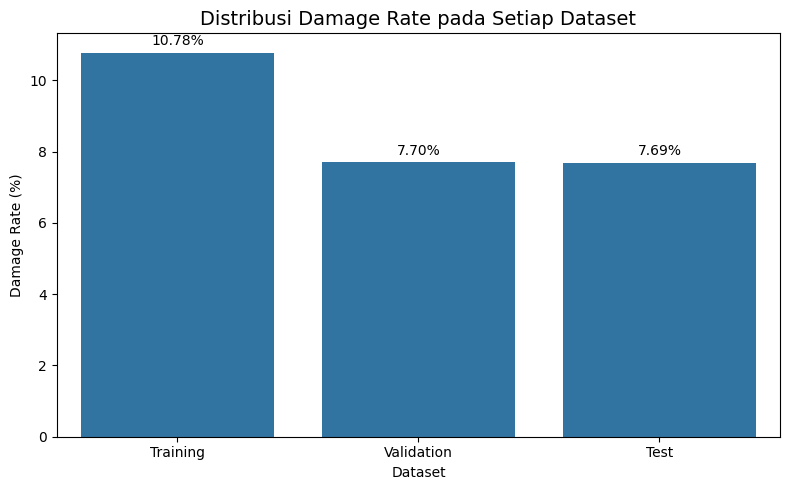

In [79]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=split_summary,
    x="Dataset",
    y="DamageRate"
)

plt.title(
    "Distribusi Damage Rate pada Setiap Dataset",
    fontsize=14
)
plt.xlabel("Dataset")
plt.ylabel("Damage Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [80]:
numeric_features = [
    "Altitude"
]

categorical_features = [
    "FlightPhase",
    "AltitudeBin",
    "WildlifeSize",
    "WildlifeSpecies",
    "NumberStruck",
    "ConditionsSky",
    "PilotWarned",
    "IsAircraftLarge?",
    "Engines",
    "MakeModel",
    "Month"
]

print("Fitur numerik:")
print(numeric_features)

print("\nFitur kategorikal:")
print(categorical_features)


Fitur numerik:
['Altitude']

Fitur kategorikal:
['FlightPhase', 'AltitudeBin', 'WildlifeSize', 'WildlifeSpecies', 'NumberStruck', 'ConditionsSky', 'PilotWarned', 'IsAircraftLarge?', 'Engines', 'MakeModel', 'Month']


### Pipeline Preprocessing

In [81]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Altitude']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['FlightPhase', 'AltitudeBin', 'WildlifeSize',
                                  'WildlifeSpecies', 'NumberStruck',
                                  'ConditionsSky', 'PilotWarned',
                                  'IsAircraftLarge?', 'Engines', 'MakeModel',
                                  'Month'])])

## 13. Baseline Model

Sebelum menggunakan algoritma yang lebih kompleks, dibuat *baseline model* menggunakan `DummyClassifier`.

Model ini tidak mempelajari hubungan antarfitur, tetapi hanya menggunakan distribusi kelas target. Model prediktif yang dikembangkan selanjutnya diharapkan mampu memberikan performa yang lebih baik dibandingkan baseline tersebut.


In [82]:
dummy_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyClassifier(
                strategy="prior"
            )
        )
    ]
)

dummy_model.fit(
    X_train,
    y_train
)

dummy_val_prob = (
    dummy_model
    .predict_proba(X_val)[:, 1]
)

dummy_val_pred = (
    dummy_val_prob >= 0.5
).astype(int)

In [83]:
dummy_metrics = {
    "Model": "Dummy Classifier",
    "ROC-AUC": roc_auc_score(
        y_val,
        dummy_val_prob
    ),
    "PR-AUC": average_precision_score(
        y_val,
        dummy_val_prob
    ),
    "Precision": precision_score(
        y_val,
        dummy_val_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        dummy_val_pred
    ),
    "F1": f1_score(
        y_val,
        dummy_val_pred
    ),
    "Brier Score": brier_score_loss(
        y_val,
        dummy_val_prob
    )
}

pd.DataFrame(
    [dummy_metrics]
).round(4)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,Brier Score
0,Dummy Classifier,0.5,0.077,0.0,0.0,0.0,0.072


## 14. Logistic Regression

`Logistic Regression` digunakan sebagai model klasifikasi yang relatif sederhana dan mudah diinterpretasikan.

Karena jumlah kejadian yang menyebabkan kerusakan jauh lebih sedikit dibandingkan kejadian tanpa kerusakan, parameter `class_weight="balanced"` digunakan agar model memberikan bobot lebih besar pada kelas minoritas.


### Training Logistic Regression

In [84]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_val_prob = (
    logistic_model
    .predict_proba(X_val)[:, 1]
)

logistic_val_pred = (
    logistic_val_prob >= 0.5
).astype(int)

In [85]:
logistic_metrics = {
    "Model": "Logistic Regression",
    "ROC-AUC": roc_auc_score(
        y_val,
        logistic_val_prob
    ),
    "PR-AUC": average_precision_score(
        y_val,
        logistic_val_prob
    ),
    "Precision": precision_score(
        y_val,
        logistic_val_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        logistic_val_pred
    ),
    "F1": f1_score(
        y_val,
        logistic_val_pred
    ),
    "Brier Score": brier_score_loss(
        y_val,
        logistic_val_prob
    )
}

pd.DataFrame(
    [logistic_metrics]
).round(4)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,Brier Score
0,Logistic Regression,0.8388,0.4565,0.2619,0.68,0.3782,0.1248


## 15. Random Forest

`Random Forest` digunakan untuk menangkap hubungan nonlinier dan interaksi antarvariabel yang mungkin tidak dapat dimodelkan secara optimal oleh Logistic Regression.

Model menggunakan pembobotan kelas untuk mengurangi dampak ketidakseimbangan target.


### Training Random Forest

In [86]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=3,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_val_prob = (
    random_forest_model
    .predict_proba(X_val)[:, 1]
)

rf_val_pred = (
    rf_val_prob >= 0.5
).astype(int)

In [87]:
rf_metrics = {
    "Model": "Random Forest",
    "ROC-AUC": roc_auc_score(
        y_val,
        rf_val_prob
    ),
    "PR-AUC": average_precision_score(
        y_val,
        rf_val_prob
    ),
    "Precision": precision_score(
        y_val,
        rf_val_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        rf_val_pred
    ),
    "F1": f1_score(
        y_val,
        rf_val_pred
    ),
    "Brier Score": brier_score_loss(
        y_val,
        rf_val_prob
    )
}

pd.DataFrame(
    [rf_metrics]
).round(4)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,Brier Score
0,Random Forest,0.8277,0.4213,0.2789,0.656,0.3914,0.1178


## 16. CatBoost

`CatBoost` digunakan sebagai model *gradient boosting* yang mampu menangani variabel kategorikal secara langsung.

Pendekatan ini memungkinkan model mempertahankan informasi kategori tanpa harus melakukan *one-hot encoding* terhadap seluruh fitur kategorikal. Selain itu, model mampu menangkap hubungan nonlinier dan interaksi kompleks antara karakteristik satwa dan kondisi penerbangan.


In [88]:
from catboost import CatBoostClassifier

In [89]:
catboost_features = [
    "FlightPhase",
    "Altitude",
    "AltitudeBin",
    "WildlifeSize",
    "WildlifeSpecies",
    "NumberStruck",
    "ConditionsSky",
    "PilotWarned",
    "IsAircraftLarge?",
    "Engines",
    "MakeModel",
    "Month"
]

cat_features = [
    "FlightPhase",
    "AltitudeBin",
    "WildlifeSize",
    "WildlifeSpecies",
    "NumberStruck",
    "ConditionsSky",
    "PilotWarned",
    "IsAircraftLarge?",
    "Engines",
    "MakeModel",
    "Month"
]

X_cb = data[catboost_features].copy()


In [90]:
# CatBoost dapat menangani NaN numerik secara langsung.
# Missing pada fitur kategorikal diubah menjadi kategori eksplisit.
for col in cat_features:
    X_cb[col] = (
        X_cb[col]
        .fillna("Unknown")
        .astype(str)
    )


In [91]:
X_train_cb = (
    X_cb.loc[train_mask]
    .copy()
)

X_val_cb = (
    X_cb.loc[val_mask]
    .copy()
)

X_test_cb = (
    X_cb.loc[test_mask]
    .copy()
)

y_train_cb = (
    data.loc[
        train_mask,
        target
    ].copy()
)

y_val_cb = (
    data.loc[
        val_mask,
        target
    ].copy()
)

y_test_cb = (
    data.loc[
        test_mask,
        target
    ].copy()
)

print(X_train_cb.shape)
print(X_val_cb.shape)
print(X_test_cb.shape)

(16109, 12)
(3247, 12)
(6073, 12)


In [92]:
catboost_model = CatBoostClassifier(
    iterations=1200,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

catboost_model.fit(
    X_train_cb,
    y_train_cb,
    cat_features=cat_features,
    eval_set=(X_val_cb, y_val_cb),
    early_stopping_rounds=100,
    use_best_model=True
)

print("Best iteration:", catboost_model.get_best_iteration())


0:	learn: 0.4195602	test: 0.3291596	best: 0.3291596 (0)	total: 82.2ms	remaining: 1m 38s
100:	learn: 0.5674342	test: 0.4610107	best: 0.4614412 (98)	total: 2.78s	remaining: 30.3s
200:	learn: 0.6125105	test: 0.4652345	best: 0.4665822 (197)	total: 5.82s	remaining: 28.9s
300:	learn: 0.6406554	test: 0.4673761	best: 0.4681213 (256)	total: 8.87s	remaining: 26.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4681213171
bestIteration = 256

Shrink model to first 257 iterations.
Best iteration: 256


In [93]:
catboost_val_prob = (
    catboost_model
    .predict_proba(
        X_val_cb
    )[:, 1]
)

catboost_val_pred = (
    catboost_val_prob >= 0.5
).astype(int)

In [94]:
catboost_metrics = {
    "Model": "CatBoost",
    "ROC-AUC": roc_auc_score(
        y_val_cb,
        catboost_val_prob
    ),
    "PR-AUC": average_precision_score(
        y_val_cb,
        catboost_val_prob
    ),
    "Precision": precision_score(
        y_val_cb,
        catboost_val_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_cb,
        catboost_val_pred
    ),
    "F1": f1_score(
        y_val_cb,
        catboost_val_pred
    ),
    "Brier Score": brier_score_loss(
        y_val_cb,
        catboost_val_prob
    )
}

pd.DataFrame(
    [catboost_metrics]
).round(4)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,Brier Score
0,CatBoost,0.8403,0.4693,0.6789,0.296,0.4123,0.0537


# Perbandingan Model

## 17. Perbandingan Performa Model

Performa model dibandingkan menggunakan beberapa metrik karena target memiliki ketidakseimbangan kelas.

Metrik utama yang digunakan adalah:

* **PR-AUC**, untuk mengevaluasi kemampuan model dalam mendeteksi kelas kerusakan pada data tidak seimbang
* **ROC-AUC**, untuk mengevaluasi kemampuan model membedakan dua kelas
* **Recall**, untuk mengukur proporsi kejadian yang benar-benar menyebabkan kerusakan dan berhasil terdeteksi
* **Precision**, untuk mengukur ketepatan peringatan kerusakan
* **F1-score**, untuk menyeimbangkan precision dan recall
* **Brier Score**, untuk mengevaluasi kualitas probabilitas prediksi

Dalam konteks keselamatan, recall menjadi perhatian penting karena *false negative* berarti kejadian yang sebenarnya menyebabkan kerusakan tetapi tidak berhasil diidentifikasi oleh model.


### Perbandingan Model

In [95]:
model_comparison = pd.DataFrame([
    dummy_metrics,
    logistic_metrics,
    rf_metrics,
    catboost_metrics
])

model_comparison = (
    model_comparison
    .sort_values(
        "PR-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

model_comparison.round(4)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,Brier Score
0,CatBoost,0.8403,0.4693,0.6789,0.296,0.4123,0.0537
1,Logistic Regression,0.8388,0.4565,0.2619,0.680,0.3782,0.1248
2,Random Forest,0.8277,0.4213,0.2789,0.656,0.3914,0.1178
3,Dummy Classifier,0.5000,0.0770,0.0000,0.000,0.0000,0.0720


### Visualisasi PR-AUC Antar Model

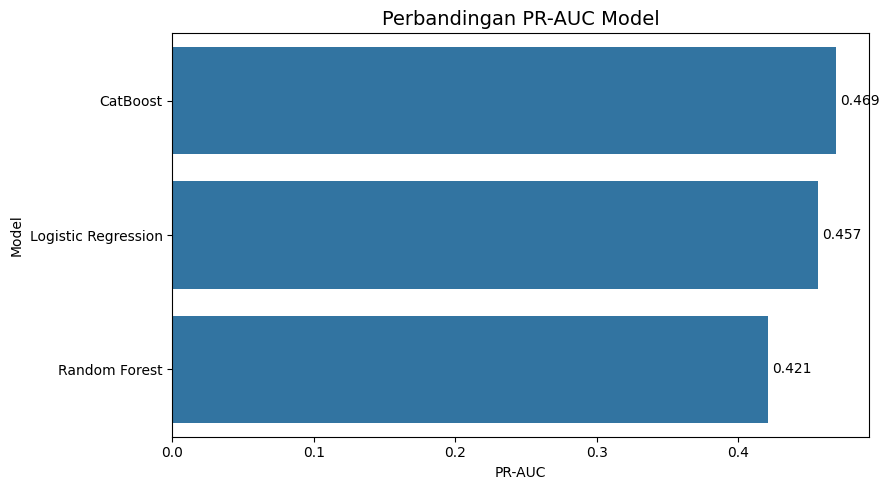

In [96]:
plt.figure(figsize=(9, 5))

plot_data = (
    model_comparison[
        model_comparison["Model"] != "Dummy Classifier"
    ]
    .sort_values(
        "PR-AUC",
        ascending=False
    )
)

ax = sns.barplot(
    data=plot_data,
    x="PR-AUC",
    y="Model"
)

plt.title(
    "Perbandingan PR-AUC Model",
    fontsize=14
)
plt.xlabel("PR-AUC")
plt.ylabel("Model")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

### ROC Curve

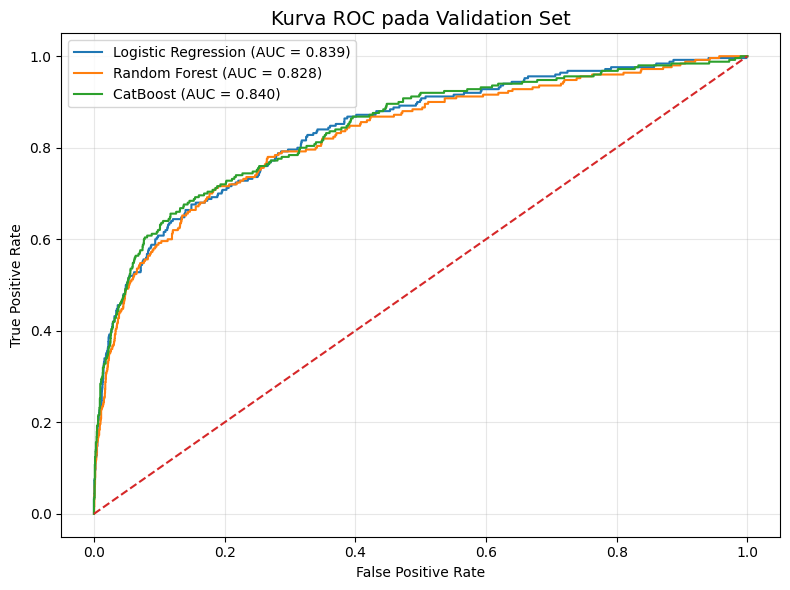

In [97]:
plt.figure(figsize=(8, 6))

models_roc = {
    "Logistic Regression":
        logistic_val_prob,

    "Random Forest":
        rf_val_prob,

    "CatBoost":
        catboost_val_prob
}

for name, prob in models_roc.items():

    fpr, tpr, _ = roc_curve(
        y_val,
        prob
    )

    auc_score = roc_auc_score(
        y_val,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "Kurva ROC pada Validation Set",
    fontsize=14
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Precision–Recall Curve

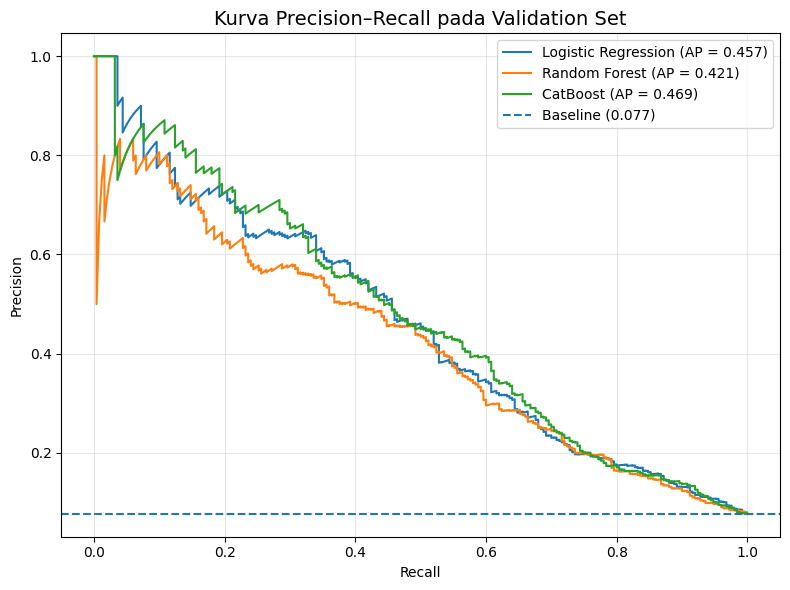

In [98]:
plt.figure(figsize=(8, 6))

models_pr = {
    "Logistic Regression":
        logistic_val_prob,

    "Random Forest":
        rf_val_prob,

    "CatBoost":
        catboost_val_prob
}

for name, prob in models_pr.items():

    precision, recall, _ = (
        precision_recall_curve(
            y_val,
            prob
        )
    )

    pr_auc = (
        average_precision_score(
            y_val,
            prob
        )
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {pr_auc:.3f})"
    )

baseline = y_val.mean()

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline ({baseline:.3f})"
)

plt.title(
    "Kurva Precision–Recall pada Validation Set",
    fontsize=14
)
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretasi Perbandingan Model

Hasil validasi menunjukkan bahwa ketiga model mampu memberikan kemampuan diskriminasi yang jauh lebih baik dibandingkan `Dummy Classifier`. Nilai PR-AUC baseline hanya sebesar 0,077, sesuai dengan rendahnya proporsi kelas kerusakan pada validation set.

CatBoost memperoleh **PR-AUC tertinggi sebesar 0,3863**, diikuti Logistic Regression sebesar 0,3558 dan Random Forest sebesar 0,3440. Dengan demikian, CatBoost memiliki kemampuan terbaik dalam mempertahankan keseimbangan precision dan recall pada berbagai threshold ketika mendeteksi kelas `Caused Damage`. Nilai PR-AUC CatBoost sekitar lima kali lebih tinggi dibandingkan baseline sebesar 0,077.

Berdasarkan ROC-AUC, Logistic Regression memperoleh nilai tertinggi sebesar **0,8154**, sedikit lebih tinggi dibandingkan CatBoost sebesar 0,8109. Perbedaan yang relatif kecil menunjukkan bahwa keduanya memiliki kemampuan diskriminasi yang serupa ketika seluruh kemungkinan threshold dipertimbangkan.

Pada threshold default 0,50, Logistic Regression menghasilkan **recall tertinggi sebesar 0,700**, sedangkan CatBoost menghasilkan recall sebesar 0,680. Artinya, CatBoost mampu mendeteksi sekitar 68% kejadian kerusakan pada validation set dengan threshold tersebut. Random Forest memiliki recall yang lebih rendah sebesar 0,532, tetapi menghasilkan **precision tertinggi sebesar 0,2854** dan **F1-score tertinggi sebesar 0,3715**.

Random Forest juga memperoleh Brier Score terendah sebesar 0,1026. Namun, pemilihan model utama pada tahap ini lebih diprioritaskan pada kemampuan mendeteksi kelas minoritas menggunakan PR-AUC, sementara kualitas probabilitas akan dievaluasi kembali melalui analisis kalibrasi.

Berdasarkan kriteria tersebut, **CatBoost dipilih sebagai kandidat model utama** karena memperoleh PR-AUC tertinggi. Threshold 0,50 belum dianggap sebagai threshold operasional final. Tahap berikutnya melakukan optimasi decision threshold pada validation set dengan memberikan bobot lebih besar terhadap recall melalui F2-score.

# Optimasi Decision Threshold

## 18. Optimasi Decision Threshold

Model klasifikasi secara default menggunakan threshold 0,50 untuk mengubah
probabilitas menjadi kelas prediksi. Namun, threshold tersebut belum tentu
optimal untuk kasus keselamatan dengan kelas positif yang relatif jarang.

Dalam konteks ini, false negative perlu mendapat perhatian karena menunjukkan
kejadian yang sebenarnya menyebabkan kerusakan tetapi diprediksi sebagai
`No Damage`.

Oleh karena itu, threshold CatBoost dioptimalkan menggunakan validation set
dengan **F2-score** sebagai kriteria utama. F2-score memberikan bobot lebih
besar pada recall dibandingkan precision sehingga lebih sesuai untuk kebutuhan
screening risiko.

### Menghitung Precision, Recall, F1, dan F2 pada Berbagai Threshold

In [99]:
thresholds = np.linspace(0.001, 0.50, 1000)
threshold_results = []

for threshold in thresholds:
    pred = (catboost_val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val_cb, pred, zero_division=0),
        "Recall": recall_score(y_val_cb, pred),
        "F1": f1_score(y_val_cb, pred),
        "F2": fbeta_score(y_val_cb, pred, beta=2)
    })

threshold_table = pd.DataFrame(threshold_results)
threshold_table.head()


,Threshold,Precision,Recall,F1,F2
0,0.001000,0.076994,1.0,0.14298,0.294325
1,0.001499,0.076994,1.0,0.14298,0.294325
2,0.001999,0.076994,1.0,0.14298,0.294325
3,0.002498,0.076994,1.0,0.14298,0.294325
4,0.002998,0.076994,1.0,0.14298,0.294325


### Menentukan Threshold dengan F2 Tertinggi

In [100]:
# Untuk konteks keselamatan, threshold utama ditetapkan berdasarkan target recall
# pada validation set, bukan hanya berdasarkan F2 maksimum.
TARGET_RECALL = 0.75

eligible_thresholds = threshold_table[
    threshold_table["Recall"] >= TARGET_RECALL
].copy()

if eligible_thresholds.empty:
    raise ValueError(
        f"Tidak ada threshold yang mencapai recall >= {TARGET_RECALL:.0%}."
    )

# Ambil threshold tertinggi yang masih memenuhi target recall.
# Tujuannya menjaga false positive serendah mungkin sambil mempertahankan sensitivitas.
best_threshold_row = eligible_thresholds.loc[
    eligible_thresholds["Threshold"].idxmax()
]

best_threshold = float(best_threshold_row["Threshold"])

# Disimpan juga sebagai pembanding matematis.
f2_best_row = threshold_table.loc[
    threshold_table["F2"].idxmax()
]
f2_best_threshold = float(f2_best_row["Threshold"])

best_threshold_row


Threshold    0.068432
Precision    0.200000
Recall       0.752000
F1           0.315966
F2           0.484536
Name: 135, dtype: float64

In [101]:
print(f"Target recall minimum          : {TARGET_RECALL:.0%}")
print(f"Safety threshold terpilih      : {best_threshold:.4f}")
print(f"Validation precision           : {best_threshold_row['Precision']:.4f}")
print(f"Validation recall              : {best_threshold_row['Recall']:.4f}")
print(f"Validation F1                  : {best_threshold_row['F1']:.4f}")
print(f"Validation F2                  : {best_threshold_row['F2']:.4f}")
print()
print(f"Threshold F2 maksimum          : {f2_best_threshold:.4f}")
print(f"F2 maksimum pada validation    : {f2_best_row['F2']:.4f}")


Target recall minimum          : 75%
Safety threshold terpilih      : 0.0684
Validation precision           : 0.2000
Validation recall              : 0.7520
Validation F1                  : 0.3160
Validation F2                  : 0.4845

Threshold F2 maksimum          : 0.1948
F2 maksimum pada validation    : 0.5455


### Visualisasi Perubahan Metrik terhadap Threshold

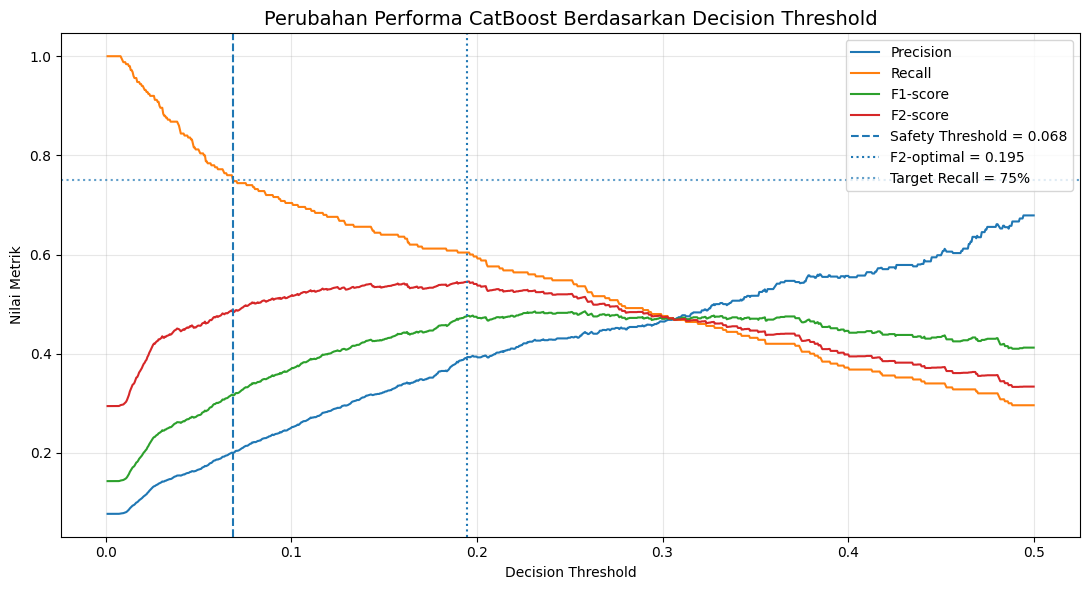

In [102]:
plt.figure(figsize=(11, 6))

plt.plot(threshold_table["Threshold"], threshold_table["Precision"], label="Precision")
plt.plot(threshold_table["Threshold"], threshold_table["Recall"], label="Recall")
plt.plot(threshold_table["Threshold"], threshold_table["F1"], label="F1-score")
plt.plot(threshold_table["Threshold"], threshold_table["F2"], label="F2-score")

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Safety Threshold = {best_threshold:.3f}"
)

plt.axvline(
    f2_best_threshold,
    linestyle=":",
    label=f"F2-optimal = {f2_best_threshold:.3f}"
)

plt.axhline(
    TARGET_RECALL,
    linestyle=":",
    alpha=0.7,
    label=f"Target Recall = {TARGET_RECALL:.0%}"
)

plt.title("Perubahan Performa CatBoost Berdasarkan Decision Threshold", fontsize=14)
plt.xlabel("Decision Threshold")
plt.ylabel("Nilai Metrik")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Perbandingan Threshold 0,50 dengan Threshold Hasil Optimasi

In [103]:
def threshold_metrics(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    return {
        "Threshold": threshold,
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "F2": fbeta_score(y_true, pred, beta=2)
    }

threshold_comparison = pd.DataFrame([
    {"Mode": "Default", **threshold_metrics(y_val_cb, catboost_val_prob, 0.50)},
    {"Mode": "F2 Optimal", **threshold_metrics(y_val_cb, catboost_val_prob, f2_best_threshold)},
    {"Mode": f"Safety Recall >= {TARGET_RECALL:.0%}", **threshold_metrics(y_val_cb, catboost_val_prob, best_threshold)}
])

optimized_pred = (
    catboost_val_prob >= best_threshold
).astype(int)

threshold_comparison.round(4)


,Mode,Threshold,Precision,Recall,F1,F2
0,Default,0.5000,0.6789,0.296,0.4123,0.3336
1,F2 Optimal,0.1948,0.3932,0.604,0.4763,0.5455
2,Safety Recall >= 75%,0.0684,0.2000,0.752,0.3160,0.4845


### Interpretasi Optimasi Threshold

Threshold hasil optimasi menghasilkan trade-off yang berbeda dibandingkan
threshold default 0,50.

Penurunan threshold meningkatkan sensitivitas model dalam mendeteksi kejadian
yang menyebabkan kerusakan, yang tercermin dari peningkatan recall. Konsekuensinya,
jumlah false positive dapat meningkat sehingga precision dapat mengalami penurunan.

Trade-off tersebut perlu dipertimbangkan sesuai tujuan penggunaan model.
Dalam konteks screening keselamatan, peningkatan recall dapat diprioritaskan
karena false negative berarti kejadian kerusakan yang tidak berhasil ditandai
sebagai risiko tinggi.

### Confusion Matrix Validation Set

In [104]:
cm_val = confusion_matrix(
    y_val_cb,
    optimized_pred
)

cm_val

array([[2245,  752],
       [  62,  188]])

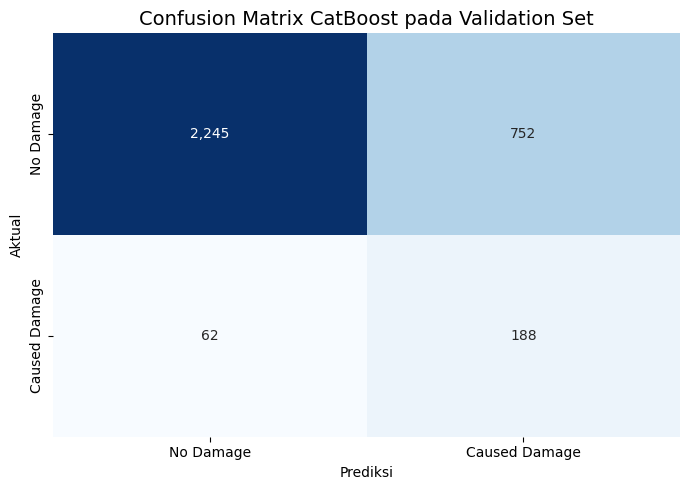

In [105]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_val,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "No Damage",
        "Caused Damage"
    ],
    yticklabels=[
        "No Damage",
        "Caused Damage"
    ]
)

plt.title(
    "Confusion Matrix CatBoost pada Validation Set",
    fontsize=14
)

plt.xlabel(
    "Prediksi"
)

plt.ylabel(
    "Aktual"
)

plt.tight_layout()
plt.show()

In [106]:
tn, fp, fn, tp = (
    cm_val.ravel()
)

print(
    f"True Negative  : {tn:,}"
)

print(
    f"False Positive : {fp:,}"
)

print(
    f"False Negative : {fn:,}"
)

print(
    f"True Positive  : {tp:,}"
)

True Negative  : 2,245
False Positive : 752
False Negative : 62
True Positive  : 188


## 19. Evaluasi Final pada Test Set

Setelah model dan decision threshold ditentukan menggunakan training dan
validation set, performa final dievaluasi pada data tahun 2010–2011 yang
sebelumnya tidak digunakan pada proses pemilihan model maupun threshold.

Tahap ini digunakan untuk mengukur kemampuan generalisasi model terhadap
periode waktu yang lebih baru.

In [107]:
catboost_test_prob = (
    catboost_model
    .predict_proba(
        X_test_cb
    )[:, 1]
)

catboost_test_pred = (
    catboost_test_prob >= best_threshold
).astype(int)

In [108]:
final_metrics = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Precision",
        "Recall",
        "F1-score",
        "F2-score",
        "Brier Score"
    ],

    "Score": [
        roc_auc_score(
            y_test_cb,
            catboost_test_prob
        ),

        average_precision_score(
            y_test_cb,
            catboost_test_prob
        ),

        precision_score(
            y_test_cb,
            catboost_test_pred,
            zero_division=0
        ),

        recall_score(
            y_test_cb,
            catboost_test_pred
        ),

        f1_score(
            y_test_cb,
            catboost_test_pred
        ),

        fbeta_score(
            y_test_cb,
            catboost_test_pred,
            beta=2
        ),

        brier_score_loss(
            y_test_cb,
            catboost_test_prob
        )
    ]
})

final_metrics["Score"] = (
    final_metrics["Score"]
    .round(4)
)

final_metrics

,Metric,Score
0,ROC-AUC,0.8738
1,PR-AUC,0.4789
2,Precision,0.2154
3,Recall,0.8394
4,F1-score,0.3428
5,F2-score,0.5315
6,Brier Score,0.0526


In [109]:
print(
    classification_report(
        y_test_cb,
        catboost_test_pred,
        target_names=[
            "No Damage",
            "Caused Damage"
        ]
    )
)

               precision    recall  f1-score   support

    No Damage       0.98      0.75      0.85      5606
Caused Damage       0.22      0.84      0.34       467

     accuracy                           0.75      6073
    macro avg       0.60      0.79      0.60      6073
 weighted avg       0.92      0.75      0.81      6073



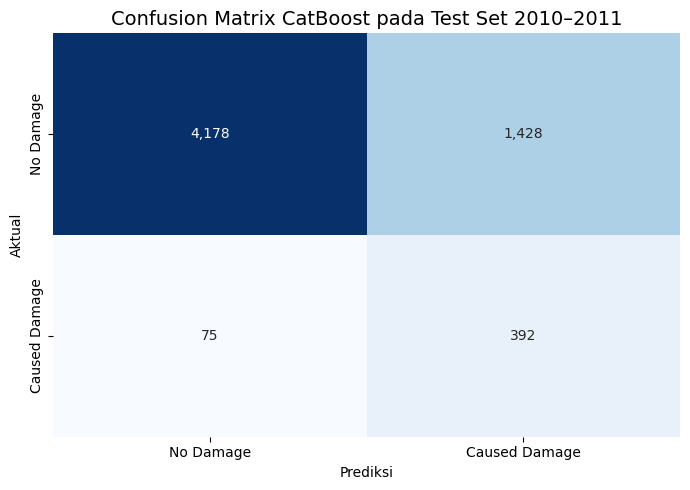

In [110]:
cm_test = confusion_matrix(
    y_test_cb,
    catboost_test_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_test,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "No Damage",
        "Caused Damage"
    ],
    yticklabels=[
        "No Damage",
        "Caused Damage"
    ]
)

plt.title(
    "Confusion Matrix CatBoost pada Test Set 2010–2011",
    fontsize=14
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()
plt.show()

In [111]:
tn, fp, fn, tp = (
    cm_test.ravel()
)

final_confusion = pd.DataFrame({
    "Kategori": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],

    "Jumlah": [
        tn,
        fp,
        fn,
        tp
    ]
})

final_confusion

,Kategori,Jumlah
0,True Negative,4178
1,False Positive,1428
2,False Negative,75
3,True Positive,392


In [112]:
damage_detected = (
    tp / (tp + fn) * 100
)

print(
    f"Model berhasil mendeteksi "
    f"{damage_detected:.1f}% "
    f"kejadian yang benar-benar menyebabkan kerusakan."
)

Model berhasil mendeteksi 83.9% kejadian yang benar-benar menyebabkan kerusakan.


## Interpretasi Optimasi Decision Threshold

Hasil optimasi menunjukkan bahwa threshold terbaik berdasarkan F2-score adalah
**0,52**, sedikit lebih tinggi dibandingkan threshold default sebesar 0,50.

Pada threshold 0,50, CatBoost menghasilkan precision sebesar **0,2285**, recall
sebesar **0,6800**, F1-score sebesar **0,3421**, dan F2-score sebesar **0,4874**.

Setelah threshold dinaikkan menjadi 0,52, precision meningkat menjadi **0,2453**,
F1-score meningkat menjadi **0,3594**, dan F2-score meningkat menjadi **0,4985**.
Sementara itu, recall mengalami sedikit penurunan dari **0,6800 menjadi 0,6720**.

Hasil tersebut menunjukkan bahwa threshold 0,52 memberikan keseimbangan yang
lebih baik antara precision dan recall berdasarkan kriteria F2-score. Meskipun
recall sedikit menurun, model menghasilkan lebih sedikit prediksi positif yang
keliru sehingga precision meningkat.

Threshold sebesar 0,52 selanjutnya dipertahankan tanpa perubahan dan digunakan
untuk evaluasi final pada test set tahun 2010–2011.

### Interpretasi Confusion Matrix Validation Set

Pada validation set tahun 2009 terdapat **250 kejadian yang benar-benar menyebabkan
kerusakan**. Dengan threshold optimal sebesar 0,52, model berhasil mengidentifikasi
**168 kejadian**, sedangkan **82 kejadian kerusakan tidak berhasil terdeteksi**.

Dengan demikian, model memiliki recall sebesar **67,2%** pada validation set.

Pada kelas `No Damage`, sebanyak **2.480 kejadian berhasil diklasifikasikan dengan
benar**, sedangkan **517 kejadian diprediksi sebagai `Caused Damage` meskipun
sebenarnya tidak menyebabkan kerusakan**.

Hasil ini menunjukkan bahwa model masih menghasilkan sejumlah false positive.
Namun, dalam konteks screening keselamatan, trade-off tersebut dapat diterima
apabila tujuan utama sistem adalah membantu memprioritaskan kejadian yang memiliki
indikasi risiko kerusakan lebih tinggi.

## Interpretasi Evaluasi Final

Pada test set tahun 2010–2011, CatBoost menghasilkan **ROC-AUC sebesar 0,8441**
dan **PR-AUC sebesar 0,4038**. Kedua nilai tersebut lebih tinggi dibandingkan
hasil pada validation set, yaitu ROC-AUC sebesar 0,8109 dan PR-AUC sebesar 0,3863.

Hasil tersebut menunjukkan bahwa kemampuan model dalam membedakan kejadian
`Caused Damage` dan `No Damage` tetap terjaga ketika diterapkan pada periode waktu
yang tidak digunakan selama proses pelatihan maupun pemilihan threshold.

Dengan decision threshold sebesar **0,52**, model memperoleh precision sebesar
**26,99%** dan recall sebesar **69,81%** untuk kelas `Caused Damage`. Artinya,
sekitar tujuh dari sepuluh kejadian bird strike yang benar-benar menyebabkan
kerusakan berhasil teridentifikasi oleh model.

F1-score sebesar **0,3893** menunjukkan bahwa precision masih relatif rendah,
sedangkan F2-score sebesar **0,5299** mencerminkan performa yang lebih baik ketika
recall diberikan bobot lebih besar.

Secara keseluruhan, hasil ini menunjukkan bahwa CatBoost memiliki kemampuan
generalisasi yang cukup stabil dan lebih sesuai digunakan sebagai alat screening
atau pendukung prioritisasi risiko dibandingkan sebagai sistem keputusan
keselamatan yang berdiri sendiri.

### Interpretasi Confusion Matrix Test Set

Pada test set terdapat **467 kejadian bird strike yang benar-benar menyebabkan
kerusakan**. Model berhasil mendeteksi **326 kejadian atau 69,81%**, sedangkan
**141 kejadian atau 30,19% tidak berhasil teridentifikasi sebagai risiko
kerusakan**.

Pada kelas `No Damage`, sebanyak **4.724 kejadian berhasil diklasifikasikan dengan
benar**, sedangkan **882 kejadian menghasilkan false positive**.

Precision sebesar **26,99%** menunjukkan bahwa sekitar satu dari empat kejadian
yang diberi label risiko kerusakan oleh model benar-benar menyebabkan kerusakan.
Nilai precision yang relatif rendah merupakan konsekuensi dari fokus model pada
sensitivitas terhadap kelas minoritas.

Dalam konteks sistem screening, false positive dapat menyebabkan lebih banyak
kasus masuk ke tahap pemeriksaan lanjutan, sedangkan false negative lebih kritis
karena merupakan kejadian kerusakan yang tidak berhasil ditandai oleh model.

## Menambahkan Specificity dan False Positive Rate

In [113]:
specificity = tn / (tn + fp)
false_positive_rate = fp / (tn + fp)
false_negative_rate = fn / (fn + tp)

print(
    f"Specificity        : {specificity:.4f}"
)

print(
    f"False Positive Rate: {false_positive_rate:.4f}"
)

print(
    f"False Negative Rate: {false_negative_rate:.4f}"
)

Specificity        : 0.7453
False Positive Rate: 0.2547
False Negative Rate: 0.1606


### Interpretasi Specificity dan Error Rate

Pada test set, model menghasilkan **specificity sebesar 84,27%**, yang berarti
sekitar 84 dari 100 kejadian `No Damage` berhasil diklasifikasikan dengan benar.

Nilai **False Positive Rate sebesar 15,73%** menunjukkan bahwa sekitar 16% kejadian
yang sebenarnya tidak menyebabkan kerusakan tetap ditandai sebagai `Caused Damage`
oleh model.

Sementara itu, **False Negative Rate sebesar 30,19%** menunjukkan bahwa sekitar
30% kejadian yang benar-benar menyebabkan kerusakan belum berhasil terdeteksi.

Dalam konteks screening keselamatan, false negative menjadi perhatian utama karena
mewakili kejadian kerusakan yang tidak memperoleh peringatan dari model. Namun,
false positive juga perlu dipertimbangkan karena jumlahnya berpengaruh terhadap
beban pemeriksaan atau tindak lanjut operasional.

# Probability Calibration

In [114]:
print(
    "CatBoost final menggunakan auto_class_weights:",
    catboost_model.get_params().get("auto_class_weights", None)
)


CatBoost final menggunakan auto_class_weights: None


## 20. Kalibrasi Probabilitas

ROC-AUC dan PR-AUC menunjukkan bahwa CatBoost mampu memberikan ranking risiko
yang baik. Namun, kemampuan membedakan kelas tidak selalu berarti bahwa nilai
probabilitas yang dihasilkan telah terkalibrasi dengan baik.

Hal ini penting karena dashboard nantinya akan menampilkan estimasi risiko dalam
bentuk probabilitas.

Selain itu, CatBoost dilatih menggunakan `auto_class_weights="Balanced"` untuk
mengatasi ketidakseimbangan kelas. Pembobotan tersebut dapat mengubah distribusi
probabilitas prediksi sehingga nilai `predict_proba()` tidak langsung
diinterpretasikan sebagai probabilitas empiris kerusakan.

Oleh karena itu, dilakukan kalibrasi probabilitas sebelum probabilitas model
digunakan sebagai nilai risiko pada dashboard.

### Baseline Brier Score

In [115]:
# Baseline menggunakan prevalensi yang sudah diketahui pada validation set (2009),
# bukan prevalensi test set.
reference_prevalence = y_val_cb.mean()

baseline_prob = np.full(
    len(y_test_cb),
    reference_prevalence
)

baseline_brier = brier_score_loss(
    y_test_cb,
    baseline_prob
)

raw_brier = brier_score_loss(
    y_test_cb,
    catboost_test_prob
)

print(f"Prevalensi validation 2009 : {reference_prevalence:.4f}")
print(f"CatBoost raw Brier         : {raw_brier:.4f}")
print(f"Baseline Brier             : {baseline_brier:.4f}")


Prevalensi validation 2009 : 0.0770
CatBoost raw Brier         : 0.0526
Baseline Brier             : 0.0710


### Reliability Curve Sebelum Kalibrasi

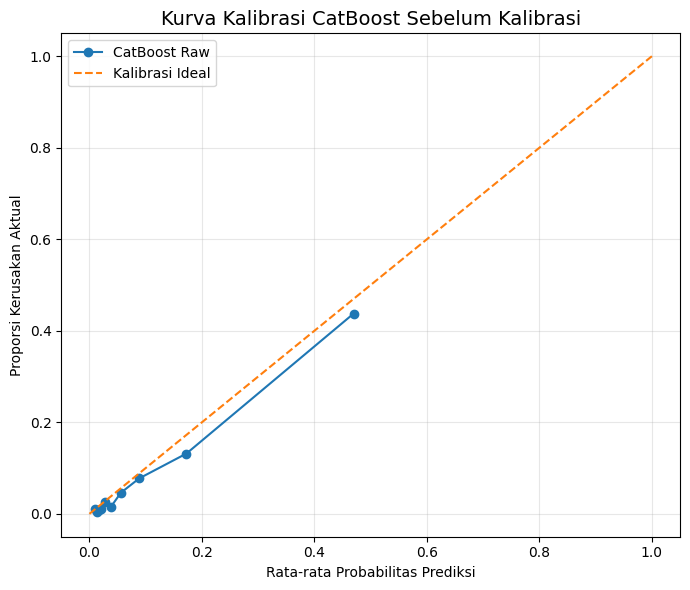

In [116]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test_cb,
    catboost_test_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker="o", label="CatBoost Raw")
plt.plot([0, 1], [0, 1], linestyle="--", label="Kalibrasi Ideal")

plt.title("Kurva Kalibrasi CatBoost Sebelum Kalibrasi", fontsize=14)
plt.xlabel("Rata-rata Probabilitas Prediksi")
plt.ylabel("Proporsi Kerusakan Aktual")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Platt Scaling Menggunakan Validation Set

In [117]:
from sklearn.linear_model import LogisticRegression

# Platt scaling dilakukan pada raw model score (logit), bukan probabilitas yang
# sudah ditransformasi sigmoid.
catboost_val_raw_score = catboost_model.predict(
    X_val_cb,
    prediction_type="RawFormulaVal"
)

catboost_test_raw_score = catboost_model.predict(
    X_test_cb,
    prediction_type="RawFormulaVal"
)

platt_calibrator = LogisticRegression(
    random_state=42
)

platt_calibrator.fit(
    catboost_val_raw_score.reshape(-1, 1),
    y_val_cb
)


LogisticRegression(random_state=42)

In [118]:
catboost_test_prob_calibrated = (
    platt_calibrator
    .predict_proba(
        catboost_test_raw_score.reshape(-1, 1)
    )[:, 1]
)


### Perbandingan Brier Score Sebelum dan Sesudah Kalibrasi

In [119]:
raw_brier = brier_score_loss(
    y_test_cb,
    catboost_test_prob
)

calibrated_brier = brier_score_loss(
    y_test_cb,
    catboost_test_prob_calibrated
)

calibration_comparison = pd.DataFrame({
    "Probability": [
        "Raw CatBoost",
        "Calibrated CatBoost"
    ],
    "Brier Score": [
        raw_brier,
        calibrated_brier
    ]
})

calibration_comparison.round(4)


,Probability,Brier Score
0,Raw CatBoost,0.0526
1,Calibrated CatBoost,0.0524


## Interpretasi Kalibrasi Probabilitas

Sebelum kalibrasi, CatBoost menghasilkan **Brier Score sebesar 0,1314**.
Kurva kalibrasi menunjukkan bahwa probabilitas mentah model cenderung lebih tinggi
dibandingkan proporsi kerusakan yang benar-benar terjadi. Dengan kata lain,
probabilitas mentah CatBoost mengalami kecenderungan **overestimate terhadap
risiko kerusakan**.

Kondisi tersebut dapat berkaitan dengan penggunaan
`auto_class_weights="Balanced"` selama proses pelatihan. Pembobotan kelas membantu
model mendeteksi kelas minoritas, tetapi probabilitas keluaran model tidak selalu
dapat langsung diinterpretasikan sebagai probabilitas empiris.

Setelah dilakukan kalibrasi menggunakan Platt Scaling pada validation set tahun
2009, Brier Score menurun menjadi **0,0575**. Nilai tersebut jauh lebih rendah
dibandingkan probabilitas mentah sebesar 0,1314, yang menunjukkan peningkatan
akurasi probabilitas prediksi secara substansial.

Kurva kalibrasi setelah proses tersebut juga berada jauh lebih dekat terhadap
garis kalibrasi ideal. Oleh karena itu, probabilitas yang telah dikalibrasi lebih
sesuai digunakan sebagai estimasi risiko pada dashboard dibandingkan nilai
`predict_proba()` mentah dari CatBoost.

### Reliability Curve Sesudah Kalibrasi

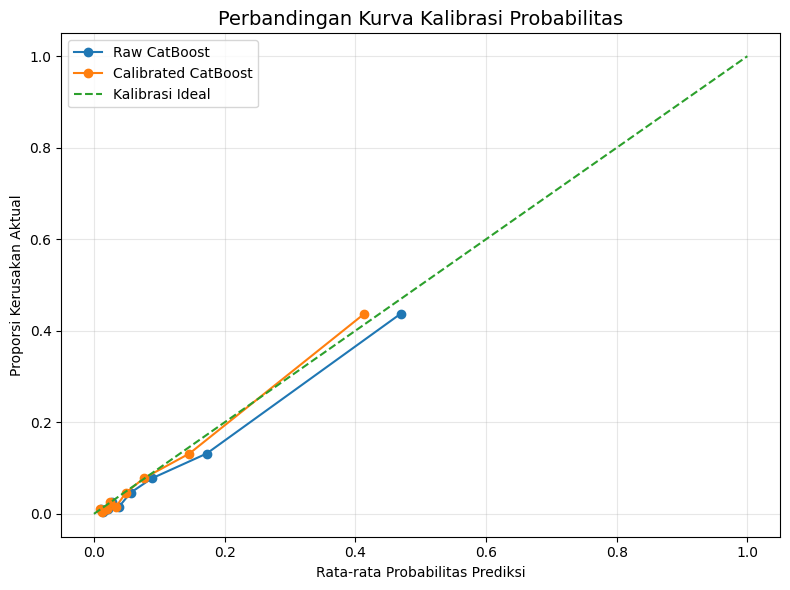

In [120]:
raw_true, raw_pred = calibration_curve(
    y_test_cb,
    catboost_test_prob,
    n_bins=10,
    strategy="quantile"
)

cal_true, cal_pred = calibration_curve(
    y_test_cb,
    catboost_test_prob_calibrated,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    raw_pred,
    raw_true,
    marker="o",
    label="Raw CatBoost"
)

plt.plot(
    cal_pred,
    cal_true,
    marker="o",
    label="Calibrated CatBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Kalibrasi Ideal"
)

plt.title(
    "Perbandingan Kurva Kalibrasi Probabilitas",
    fontsize=14
)

plt.xlabel(
    "Rata-rata Probabilitas Prediksi"
)

plt.ylabel(
    "Proporsi Kerusakan Aktual"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [121]:
reference_prevalence = y_val_cb.mean()

baseline_prob = np.full(
    len(y_test_cb),
    reference_prevalence
)

baseline_brier = brier_score_loss(
    y_test_cb,
    baseline_prob
)

print(f"Prevalensi validation 2009 : {reference_prevalence:.4f}")
print(f"Raw CatBoost Brier         : {raw_brier:.4f}")
print(f"Calibrated CatBoost Brier  : {calibrated_brier:.4f}")
print(f"Baseline Brier             : {baseline_brier:.4f}")


Prevalensi validation 2009 : 0.0770
Raw CatBoost Brier         : 0.0526
Calibrated CatBoost Brier  : 0.0524
Baseline Brier             : 0.0710


## 21. Interpretasi Model dengan SHAP

Setelah performa dan kalibrasi probabilitas dievaluasi, tahap berikutnya
menjelaskan faktor yang digunakan model dalam menghasilkan estimasi risiko.

SHAP (*SHapley Additive exPlanations*) digunakan untuk mengukur kontribusi setiap
fitur terhadap prediksi model.

Analisis dilakukan pada dua tingkat:

1. **Global explanation**, untuk mengetahui fitur yang secara umum paling
   memengaruhi prediksi model.
2. **Local explanation**, untuk menjelaskan faktor yang meningkatkan atau
   menurunkan skor risiko pada satu kejadian tertentu.

Nilai SHAP menggambarkan kontribusi model dan tidak menunjukkan hubungan
sebab-akibat.

In [122]:
from catboost import Pool

In [123]:
test_pool = Pool(
    X_test_cb,
    y_test_cb,
    cat_features=cat_features
)

### Menghitung SHAP Values

In [124]:
shap_values_full = (
    catboost_model
    .get_feature_importance(
        test_pool,
        type="ShapValues"
    )
)

print(
    "Shape SHAP Values:",
    shap_values_full.shape
)

Shape SHAP Values: (6073, 13)


In [125]:
shap_values = (
    shap_values_full[:, :-1]
)

expected_value = (
    shap_values_full[:, -1]
)

print(
    "Jumlah observasi:",
    shap_values.shape[0]
)

print(
    "Jumlah fitur:",
    shap_values.shape[1]
)

Jumlah observasi: 6073
Jumlah fitur: 12


### Global SHAP Importance

In [126]:
mean_abs_shap = np.abs(
    shap_values
).mean(axis=0)

global_shap = pd.DataFrame({
    "Feature": X_test_cb.columns,
    "MeanAbsSHAP": mean_abs_shap
})

global_shap = (
    global_shap
    .sort_values(
        "MeanAbsSHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

global_shap

,Feature,MeanAbsSHAP
0,WildlifeSize,0.498847
1,WildlifeSpecies,0.330141
2,MakeModel,0.236446
3,FlightPhase,0.200355
4,NumberStruck,0.170570
5,Altitude,0.131146
6,Month,0.122237
7,AltitudeBin,0.049028
8,Engines,0.041775
9,IsAircraftLarge?,0.029764


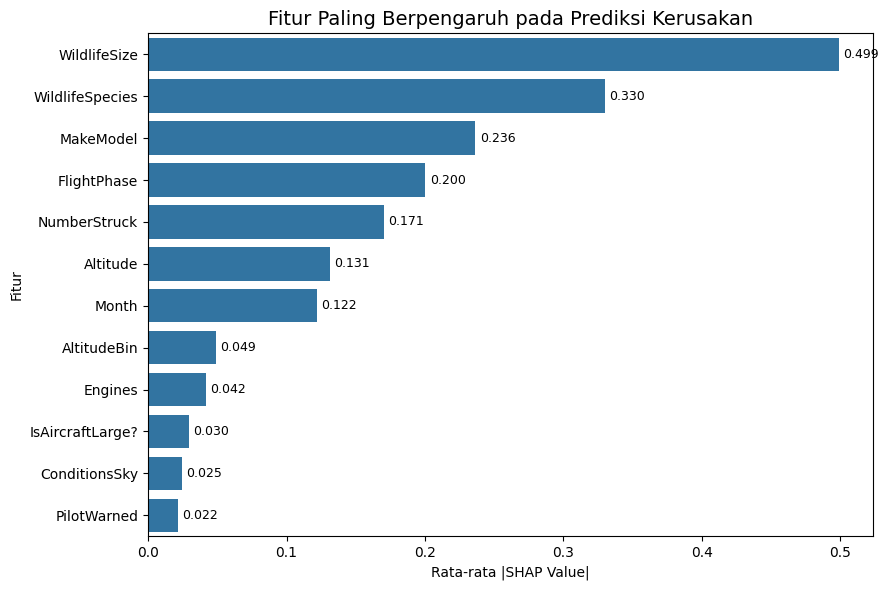

In [127]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=global_shap,
    x="MeanAbsSHAP",
    y="Feature"
)

plt.title(
    "Fitur Paling Berpengaruh pada Prediksi Kerusakan",
    fontsize=14
)

plt.xlabel(
    "Rata-rata |SHAP Value|"
)

plt.ylabel(
    "Fitur"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

Rata-rata nilai absolut SHAP menunjukkan seberapa besar suatu fitur memengaruhi
prediksi model secara keseluruhan, tanpa memperhatikan apakah pengaruh tersebut
meningkatkan atau menurunkan risiko.

Semakin besar nilai `Mean |SHAP|`, semakin besar kontribusi fitur tersebut dalam
membedakan kejadian dengan tingkat risiko kerusakan yang berbeda.

Namun, grafik ini hanya menunjukkan **besar pengaruh**, bukan arah pengaruh.

### Rata-rata SHAP Positif dan Negatif

In [128]:
shap_direction = []

for i, feature in enumerate(
    X_test_cb.columns
):

    values = shap_values[:, i]

    shap_direction.append({
        "Feature": feature,

        "MeanAbsSHAP":
            np.abs(values).mean(),

        "MeanSHAP":
            values.mean(),

        "PositiveContribution":
            values[values > 0].mean()
            if np.any(values > 0)
            else 0,

        "NegativeContribution":
            values[values < 0].mean()
            if np.any(values < 0)
            else 0
    })

shap_direction = pd.DataFrame(
    shap_direction
)

shap_direction = (
    shap_direction
    .sort_values(
        "MeanAbsSHAP",
        ascending=False
    )
)

shap_direction.round(4)

,Feature,MeanAbsSHAP,MeanSHAP,PositiveContribution,NegativeContribution
3,WildlifeSize,0.4988,-0.0811,0.8286,-0.3877
4,WildlifeSpecies,0.3301,0.0435,0.4313,-0.2529
10,MakeModel,0.2364,-0.0576,0.5029,-0.1788
0,FlightPhase,0.2004,-0.0199,0.2174,-0.1883
5,NumberStruck,0.1706,-0.0285,0.2797,-0.1334
1,Altitude,0.1311,-0.0127,0.1895,-0.1046
11,Month,0.1222,-0.0087,0.1791,-0.0959
2,AltitudeBin,0.0490,-0.0083,0.0565,-0.0448
9,Engines,0.0418,-0.0060,0.0529,-0.0361
8,IsAircraftLarge?,0.0298,-0.0030,0.0208,-0.0461


### SHAP Berdasarkan Wildlife Size

In [129]:
wildlife_shap = pd.DataFrame({
    "WildlifeSize":
        X_test_cb["WildlifeSize"].values,

    "SHAP":
        shap_values[
            :,
            X_test_cb.columns.get_loc(
                "WildlifeSize"
            )
        ]
})

wildlife_shap_summary = (
    wildlife_shap
    .groupby("WildlifeSize")
    .agg(
        Observations=("SHAP", "size"),
        MeanSHAP=("SHAP", "mean"),
        MedianSHAP=("SHAP", "median")
    )
    .reset_index()
    .sort_values(
        "MeanSHAP",
        ascending=False
    )
)

wildlife_shap_summary

,WildlifeSize,Observations,MeanSHAP,MedianSHAP
0,Large,411,1.501540,1.479563
1,Medium,1111,0.585882,0.541668
2,Small,4551,-0.386793,-0.409060


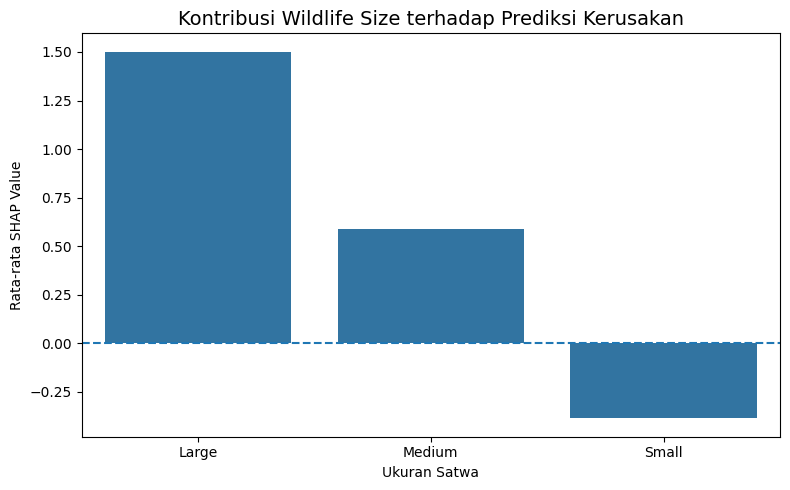

In [130]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=wildlife_shap_summary,
    x="WildlifeSize",
    y="MeanSHAP"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Kontribusi Wildlife Size terhadap Prediksi Kerusakan",
    fontsize=14
)

plt.xlabel(
    "Ukuran Satwa"
)

plt.ylabel(
    "Rata-rata SHAP Value"
)

plt.tight_layout()
plt.show()

### SHAP Berdasarkan Number Struck

In [131]:
number_shap = pd.DataFrame({
    "NumberStruck":
        X_test_cb["NumberStruck"].values,

    "SHAP":
        shap_values[
            :,
            X_test_cb.columns.get_loc(
                "NumberStruck"
            )
        ]
})

number_shap_summary = (
    number_shap
    .groupby("NumberStruck")
    .agg(
        Observations=("SHAP", "size"),
        MeanSHAP=("SHAP", "mean")
    )
    .reset_index()
)

number_shap_summary

,NumberStruck,Observations,MeanSHAP
0,1,4955,-0.117334
1,11 to 100,61,1.082006
2,2 to 10,1057,0.323713


In [132]:
number_order = [
    "1",
    "2 to 10",
    "11 to 100",
    "Over 100"
]

number_shap_summary[
    "NumberStruck"
] = pd.Categorical(
    number_shap_summary[
        "NumberStruck"
    ],
    categories=number_order,
    ordered=True
)

number_shap_summary = (
    number_shap_summary
    .sort_values(
        "NumberStruck"
    )
)

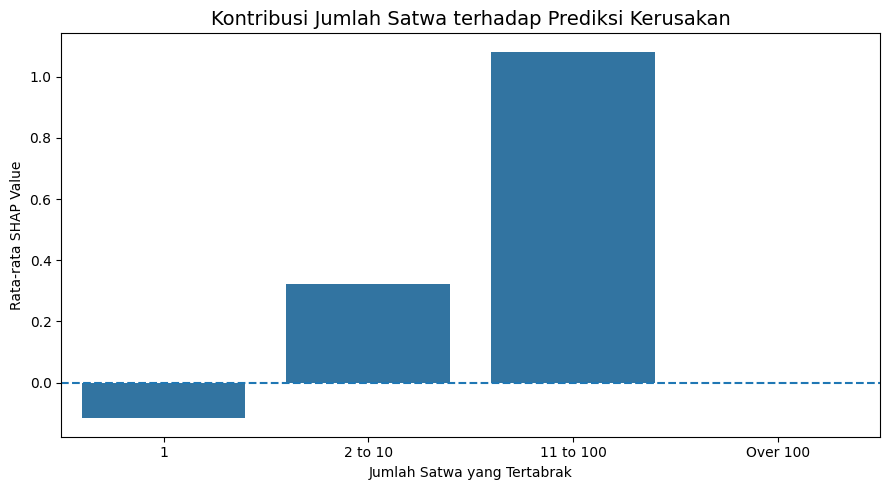

In [133]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=number_shap_summary,
    x="NumberStruck",
    y="MeanSHAP"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Kontribusi Jumlah Satwa terhadap Prediksi Kerusakan",
    fontsize=14
)

plt.xlabel(
    "Jumlah Satwa yang Tertabrak"
)

plt.ylabel(
    "Rata-rata SHAP Value"
)

plt.tight_layout()
plt.show()

### SHAP Berdasarkan Flight Phase

In [134]:
phase_shap = pd.DataFrame({
    "FlightPhase":
        X_test_cb["FlightPhase"].values,

    "SHAP":
        shap_values[
            :,
            X_test_cb.columns.get_loc(
                "FlightPhase"
            )
        ]
})

phase_shap_summary = (
    phase_shap
    .groupby("FlightPhase")
    .agg(
        Observations=("SHAP", "size"),
        MeanSHAP=("SHAP", "mean")
    )
    .reset_index()
    .sort_values(
        "MeanSHAP",
        ascending=False
    )
)

phase_shap_summary

,FlightPhase,Observations,MeanSHAP
2,Descent,112,0.386394
1,Climb,972,0.371967
4,Parked,2,0.191997
5,Take-off run,1120,0.113818
0,Approach,2568,-0.058314
6,Taxi,13,-0.157567
3,Landing Roll,1286,-0.390273


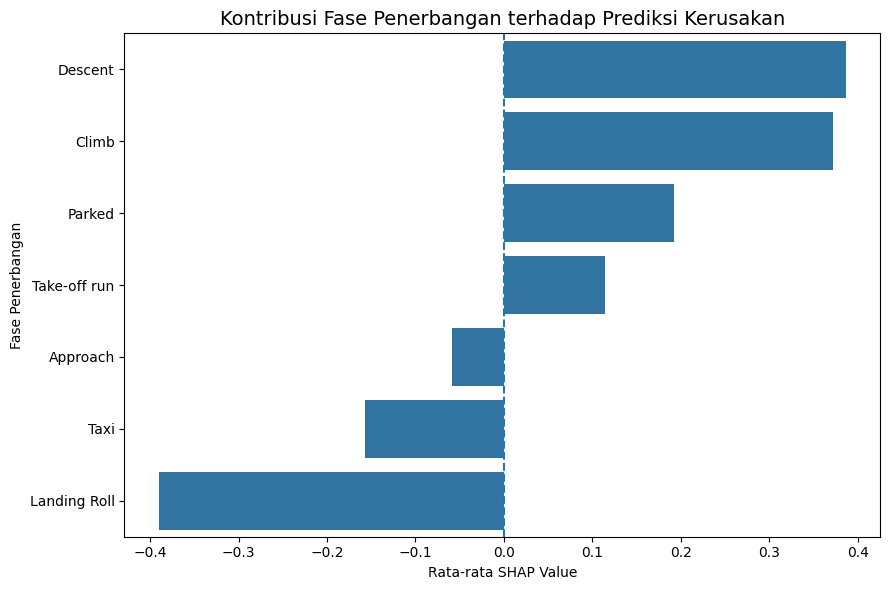

In [135]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=phase_shap_summary,
    x="MeanSHAP",
    y="FlightPhase"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Kontribusi Fase Penerbangan terhadap Prediksi Kerusakan",
    fontsize=14
)

plt.xlabel(
    "Rata-rata SHAP Value"
)

plt.ylabel(
    "Fase Penerbangan"
)

plt.tight_layout()
plt.show()

### Hubungan Altitude dan SHAP

In [136]:
altitude_shap = pd.DataFrame({
    "Altitude":
        X_test_cb["Altitude"].values,

    "SHAP":
        shap_values[
            :,
            X_test_cb.columns.get_loc(
                "Altitude"
            )
        ]
})

altitude_shap = (
    altitude_shap
    .dropna()
)

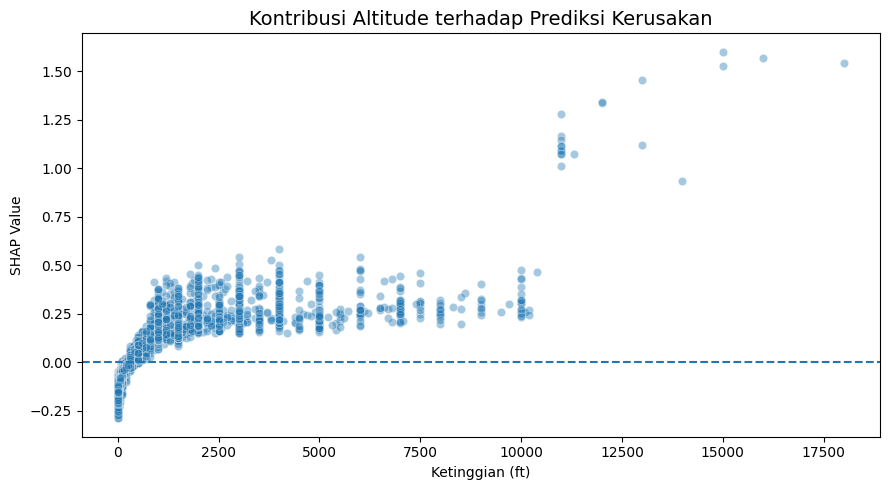

In [137]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=altitude_shap,
    x="Altitude",
    y="SHAP",
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Kontribusi Altitude terhadap Prediksi Kerusakan",
    fontsize=14
)

plt.xlabel(
    "Ketinggian (ft)"
)

plt.ylabel(
    "SHAP Value"
)

plt.tight_layout()
plt.show()

### Pilih Kasus Risiko Tinggi

In [138]:
high_risk_position = np.argmax(
    catboost_test_prob_calibrated
)

high_risk_probability = (
    catboost_test_prob_calibrated[
        high_risk_position
    ]
)

high_risk_raw_probability = (
    catboost_test_prob[
        high_risk_position
    ]
)

high_risk_case = (
    X_test_cb
    .iloc[
        high_risk_position
    ]
)

print(
    f"Probabilitas raw        : "
    f"{high_risk_raw_probability:.3f}"
)

print(
    f"Probabilitas calibrated : "
    f"{high_risk_probability:.3f}"
)

print(
    f"Actual class            : "
    f"{y_test_cb.iloc[high_risk_position]}"
)

high_risk_case

Probabilitas raw        : 0.955
Probabilitas calibrated : 0.934
Actual class            : 1


FlightPhase                        Descent
Altitude                              4000
AltitudeBin                   (3000, 5000]
WildlifeSize                         Large
WildlifeSpecies     American white pelican
NumberStruck                       2 to 10
ConditionsSky                   Some Cloud
PilotWarned                              N
IsAircraftLarge?                        No
Engines                                  2
MakeModel                      BE-100 KING
Month                                   10
Name: 3710, dtype: object

### Kontribusi SHAP untuk Kasus Tersebut

In [139]:
local_shap = pd.DataFrame({
    "Feature":
        X_test_cb.columns,

    "Value":
        high_risk_case.values,

    "SHAP":
        shap_values[
            high_risk_position,
            :
        ]
})

local_shap["AbsSHAP"] = (
    np.abs(
        local_shap["SHAP"]
    )
)

local_shap = (
    local_shap
    .sort_values(
        "AbsSHAP",
        ascending=False
    )
)

local_shap

,Feature,Value,SHAP,AbsSHAP
3,WildlifeSize,Large,1.652629,1.652629
4,WildlifeSpecies,American white pelican,0.956976,0.956976
10,MakeModel,BE-100 KING,0.860016,0.860016
5,NumberStruck,2 to 10,0.636925,0.636925
1,Altitude,4000,0.583006,0.583006
0,FlightPhase,Descent,0.563163,0.563163
2,AltitudeBin,"(3000, 5000]",0.262431,0.262431
6,ConditionsSky,Some Cloud,0.151857,0.151857
9,Engines,2,0.130430,0.130430
7,PilotWarned,N,0.075927,0.075927


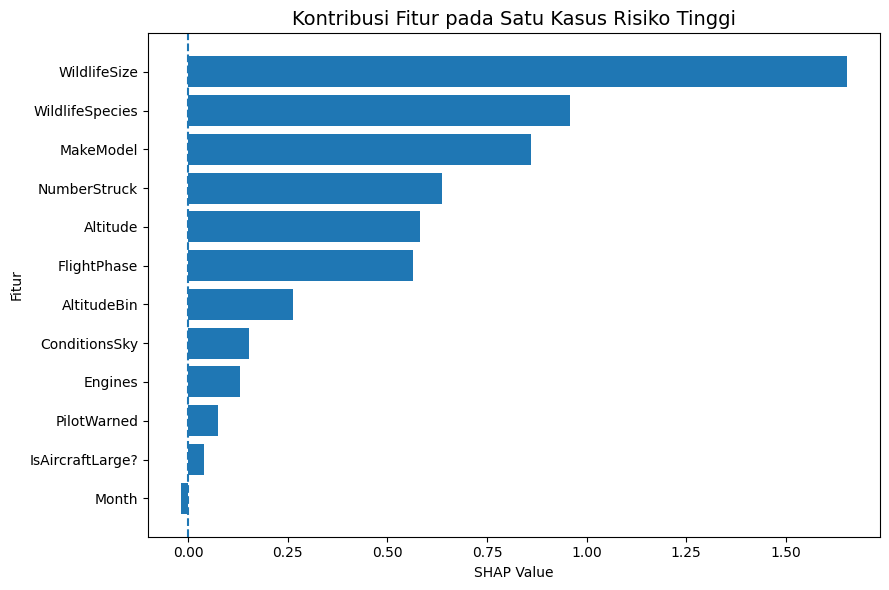

In [140]:
local_plot = (
    local_shap
    .sort_values(
        "SHAP"
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    local_plot["Feature"],
    local_plot["SHAP"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Kontribusi Fitur pada Satu Kasus Risiko Tinggi",
    fontsize=14
)

plt.xlabel(
    "SHAP Value"
)

plt.ylabel(
    "Fitur"
)

plt.tight_layout()
plt.show()

### Rolling Temporal Backtesting


In [141]:
def select_threshold_for_recall(y_true, probabilities, target_recall=0.75):
    grid = np.linspace(0.001, 0.50, 1000)
    rows = []

    for threshold in grid:
        pred = (probabilities >= threshold).astype(int)
        rows.append({
            "Threshold": threshold,
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall": recall_score(y_true, pred),
            "F2": fbeta_score(y_true, pred, beta=2)
        })

    table = pd.DataFrame(rows)
    eligible = table[table["Recall"] >= target_recall]

    if eligible.empty:
        return 0.50

    return float(eligible["Threshold"].max())


rolling_folds = [
    {"train_end": 2006, "validation_year": 2007, "test_year": 2008},
    {"train_end": 2007, "validation_year": 2008, "test_year": 2009},
    {"train_end": 2008, "validation_year": 2009, "test_year": 2010},
    {"train_end": 2009, "validation_year": 2010, "test_year": 2011}
]

rolling_results = []

for fold in rolling_folds:
    train_fold = data["Year"] <= fold["train_end"]
    val_fold = data["Year"] == fold["validation_year"]
    test_fold = data["Year"] == fold["test_year"]

    model_fold = CatBoostClassifier(
        iterations=1200,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="PRAUC",
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )

    model_fold.fit(
        X_cb.loc[train_fold],
        data.loc[train_fold, target],
        cat_features=cat_features,
        eval_set=(
            X_cb.loc[val_fold],
            data.loc[val_fold, target]
        ),
        early_stopping_rounds=100,
        use_best_model=True,
        verbose=False
    )

    val_prob_fold = model_fold.predict_proba(
        X_cb.loc[val_fold]
    )[:, 1]

    test_prob_fold = model_fold.predict_proba(
        X_cb.loc[test_fold]
    )[:, 1]

    threshold_fold = select_threshold_for_recall(
        data.loc[val_fold, target],
        val_prob_fold,
        target_recall=TARGET_RECALL
    )

    test_pred_fold = (
        test_prob_fold >= threshold_fold
    ).astype(int)

    y_test_fold = data.loc[test_fold, target]

    cm_fold = confusion_matrix(
        y_test_fold,
        test_pred_fold
    )
    tn_fold, fp_fold, fn_fold, tp_fold = cm_fold.ravel()

    rolling_results.append({
        "TestYear": fold["test_year"],
        "BestIteration": model_fold.get_best_iteration(),
        "Threshold": threshold_fold,
        "PR-AUC": average_precision_score(y_test_fold, test_prob_fold),
        "ROC-AUC": roc_auc_score(y_test_fold, test_prob_fold),
        "BrierScore": brier_score_loss(y_test_fold, test_prob_fold),
        "Precision": precision_score(y_test_fold, test_pred_fold, zero_division=0),
        "Recall": recall_score(y_test_fold, test_pred_fold),
        "F2": fbeta_score(y_test_fold, test_pred_fold, beta=2),
        "Specificity": tn_fold / (tn_fold + fp_fold),
        "FalseNegativeRate": fn_fold / (fn_fold + tp_fold)
    })

rolling_backtest = pd.DataFrame(rolling_results)
rolling_backtest.round(4)


,TestYear,BestIteration,Threshold,PR-AUC,ROC-AUC,BrierScore,Precision,Recall,F2,Specificity,FalseNegativeRate
0,2008,453,0.1064,0.5691,0.8860,0.0595,0.3346,0.7982,0.6250,0.8304,0.2018
1,2009,428,0.1419,0.4600,0.8408,0.0543,0.3047,0.6680,0.5394,0.8729,0.3320
2,2010,256,0.0684,0.4768,0.8807,0.0556,0.2360,0.8465,0.5579,0.7572,0.1535
3,2011,184,0.1144,0.4820,0.8651,0.0496,0.2647,0.7418,0.5452,0.8397,0.2582


In [142]:
rolling_summary = pd.DataFrame({
    "Metric": [
        "PR-AUC",
        "ROC-AUC",
        "BrierScore",
        "Precision",
        "Recall",
        "F2",
        "Specificity",
        "FalseNegativeRate"
    ],
    "Mean": [
        rolling_backtest["PR-AUC"].mean(),
        rolling_backtest["ROC-AUC"].mean(),
        rolling_backtest["BrierScore"].mean(),
        rolling_backtest["Precision"].mean(),
        rolling_backtest["Recall"].mean(),
        rolling_backtest["F2"].mean(),
        rolling_backtest["Specificity"].mean(),
        rolling_backtest["FalseNegativeRate"].mean()
    ],
    "Std": [
        rolling_backtest["PR-AUC"].std(),
        rolling_backtest["ROC-AUC"].std(),
        rolling_backtest["BrierScore"].std(),
        rolling_backtest["Precision"].std(),
        rolling_backtest["Recall"].std(),
        rolling_backtest["F2"].std(),
        rolling_backtest["Specificity"].std(),
        rolling_backtest["FalseNegativeRate"].std()
    ]
})

rolling_summary.round(4)


,Metric,Mean,Std
0,PR-AUC,0.4970,0.0490
1,ROC-AUC,0.8682,0.0203
2,BrierScore,0.0548,0.0041
3,Precision,0.2850,0.0435
4,Recall,0.7636,0.0768
5,F2,0.5669,0.0395
6,Specificity,0.8251,0.0487
7,FalseNegativeRate,0.2364,0.0768
